# Análisis Exploratorio de Datos — Wyscout Event Data

**TFG:** Sistema de scouting de futbolistas basado en datos: clasificación de estilos de juego y predicción de rendimiento mediante aprendizaje automático  
**Autor:** Mario Herranz Martínez — Grado en Ciencia de Datos, Universitat de València  
**Dataset:** Wyscout/Pappalardo et al. (2019), Nature Scientific Data  
**Cobertura:** Big 5 ligas europeas, temporada 2017/18 — 3.071.395 eventos espacio-temporales

---

**Objetivo:** Explorar y comprender la estructura, calidad y distribuciones del dataset de eventos
antes de proceder al feature engineering, modelo xG y clustering de estilos de juego.

**Estructura del notebook:**

0. Setup y conexión a datos
1. Descripción del dataset
2. Calidad de los datos
3. Análisis temporal
4. Análisis espacial
5. Análisis de tiros (preludio del modelo xG)
6. Análisis de pases
7. Análisis defensivo
8. Comparación entre ligas
9. Correlaciones y estructura de features
10. Perfiles de jugador (adelanto del scouting)
11. Conclusiones y conexión con fases posteriores


## 0. Setup y conexión a datos

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from mplsoccer import Pitch, VerticalPitch
from sqlalchemy import create_engine
from dotenv import load_dotenv
import os
import warnings
from scipy.ndimage import gaussian_filter
from scipy import stats
warnings.filterwarnings('ignore')

# Estilo global para todas las figuras
plt.rcParams.update({
    'figure.figsize': (12, 7),
    'figure.dpi': 100,
    'font.size': 11,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'legend.fontsize': 10,
    'figure.facecolor': 'white',
})

# Paleta de colores para las 5 ligas
LEAGUE_COLORS = {
    'Spanish first division': '#E63946',
    'English first division': '#6A0DAD',
    'Italian first division': '#1D3557',
    'German first division': '#E9C46A',
    'French first division': '#2A9D8F',
}

LEAGUE_SHORT = {
    'Spanish first division': 'La Liga',
    'English first division': 'Premier League',
    'Italian first division': 'Serie A',
    'German first division': 'Bundesliga',
    'French first division': 'Ligue 1',
}

print("Librerías importadas correctamente")


Librerías importadas correctamente


In [2]:
# Conexión a PostgreSQL
load_dotenv()

engine = create_engine(
    f"postgresql://{os.getenv('PG_USER')}:{os.getenv('PG_PASSWORD')}"
    f"@{os.getenv('PG_HOST', 'localhost')}:{os.getenv('PG_PORT', '5432')}"
    f"/{os.getenv('PG_DB', 'football_scouting')}"
)

# Test de conexión
test = pd.read_sql("SELECT COUNT(*) AS n FROM silver.event_enriched", engine)
print(f"Conectado a PostgreSQL — {test['n'].iloc[0]:,} eventos en Silver")


Conectado a PostgreSQL — 3,251,294 eventos en Silver


In [3]:
# Cargar los datos principales (solo Big 5 ligas de clubes)
# Excluimos Mundial y Euro para el análisis de clubes

df = pd.read_sql("""
    SELECT e.wy_event_id, e.event_id, e.sub_event_id, e.match_id, e.player_id, e.team_id,         
    e.match_period, e.event_sec, e.minute_in_period, e.minute_match, e.second_match, e.is_first_half, 
    e.is_second_half, e.is_extra_time, e.is_penalties, e.event_name, e.sub_event_name, e.x_m, e.y_m, 
    e.x_end_m, e.y_end_m, e.dist_to_goal_m, e.angle_to_goal_deg, e.zone_x, e.zone_y, e.zone_id, e.pass_distance_m, 
    e.pass_goal_distance_delta_m, e.is_progressive_pass, e.is_accurate, e.is_not_accurate, e.is_goal, e.is_own_goal, 
    e.is_assist, e.is_key_pass, e.body_part, e.is_left_foot, e.is_right_foot, e.is_head_body, e.is_free_space, 
    e.is_free_space_right, e.is_free_space_left, e.is_counterattack, e.is_dangerous_ball_lost, e.is_blocked, 
    e.is_opportunity, e.is_direct, e.is_indirect, e.is_yellow_card, e.is_red_card, e.is_second_yellow, 
    e.is_interception, e.is_clearance, e.is_sliding_tackle, e.is_penalty_shot, e.is_free_kick_shot, e.is_goal_low, 
    e.is_goal_mid, e.is_goal_high, e.competition_id, e.home_team_id, e.away_team_id, e.venue, c.name AS competition_name     
    FROM silver.event_enriched e     
    JOIN bronze.wyscout_competitions c
        ON e.competition_id = c.wy_competition_id     
    WHERE c.type = 'club' """, engine)

# Mapeo de nombres cortos para uso posterior
df['league'] = df['competition_name'].map(LEAGUE_SHORT)

In [4]:
# Cargar metadatos de jugadores
players = pd.read_sql("""
    SELECT wy_player_id, short_name, complete_name,
           role->>'code2' AS position_code,
           role->>'name' AS position_name,
           birth_date, foot, height
    FROM bronze.wyscout_players
""", engine)

print(f"{len(players):,} jugadores cargados")
print(f"   Posiciones: {players['position_code'].value_counts().to_dict()}")


3,603 jugadores cargados
   Posiciones: {'MD': 1257, 'DF': 1200, 'FW': 720, 'GK': 426}


## 1. Descripción del dataset

Este análisis se basa en el dataset público de eventos espacio-temporales de Wyscout,
publicado por Pappalardo et al. (2019) en *Nature Scientific Data*. El dataset contiene
todos los eventos on-the-ball (pases, tiros, duelos, faltas, etc.) registrados durante
la temporada 2017/18 de las cinco grandes ligas europeas, el Mundial 2018 y la
Eurocopa 2016.

Para este análisis nos centramos exclusivamente en las **cinco grandes ligas**,
excluyendo las competiciones de selecciones nacionales. Esto garantiza consistencia
en el número de partidos por equipo y permite comparaciones directas entre ligas.

En esta sección validamos el dataset contra las cifras publicadas en el artículo
original y describimos su estructura.


In [5]:
# Tabla resumen por competición — validación contra Pappalardo et al. (2019), Table 1
summary = df.groupby('competition_name').agg(
    partidos=('match_id', 'nunique'),
    eventos=('wy_event_id', 'count'),
    jugadores=('player_id', 'nunique'),
    goles=('is_goal', 'sum'),
).reset_index()

summary['eventos_por_partido'] = (summary['eventos'] / summary['partidos']).round(0).astype(int)
summary['goles_por_partido'] = (summary['goles'] / summary['partidos']).round(2)
summary.index = summary['competition_name'].map(LEAGUE_SHORT)
summary = summary.drop(columns='competition_name')
summary = summary.sort_values('eventos', ascending=False)

# Fila de totales
total = pd.DataFrame({
    'partidos': [summary['partidos'].sum()],
    'eventos': [summary['eventos'].sum()],
    'jugadores': [summary['jugadores'].sum()],
    'goles': [int(summary['goles'].sum())],
    'eventos_por_partido': [int(summary['eventos'].sum() / summary['partidos'].sum())],
    'goles_por_partido': [round(summary['goles'].sum() / summary['partidos'].sum(), 2)],
}, index=['TOTAL'])

summary_display = pd.concat([summary, total])
summary_display['goles'] = summary_display['goles'].astype(int)

print("Tabla 1 — Resumen del dataset por competición (solo Big 5, 2017/18)")
print("Referencia: Pappalardo et al. (2019), Nature Scientific Data 6:236\n")
print(summary_display.to_string())


Tabla 1 — Resumen del dataset por competición (solo Big 5, 2017/18)
Referencia: Pappalardo et al. (2019), Nature Scientific Data 6:236

                partidos  eventos  jugadores  goles  eventos_por_partido  goles_por_partido
Serie A              380   647372        534   1997                 1704               5.26
Premier League       380   643150        515   2007                 1692               5.28
Ligue 1              380   632807        542   2032                 1665               5.35
La Liga              380   628659        558   2018                 1654               5.31
Bundesliga           306   519407        474   1689                 1697               5.52
TOTAL               1826  3071395       2623   9743                 1682               5.34


In [6]:
# Resumen de participación por jugador
player_summary = (
    df[df['player_id'].notna()]
    .groupby('player_id')
    .agg(
        matches_played=('match_id', 'nunique'),
        total_events=('wy_event_id', 'count')
    )
    .reset_index()
)

player_summary_display = player_summary.merge(
    players[['wy_player_id', 'short_name', 'complete_name', 'position_code', 'position_name']],
    left_on='player_id',
    right_on='wy_player_id',
    how='inner' 
)

print(f"Jugadores con eventos asignados: {len(player_summary_display):,}")
print(player_summary_display[['short_name', 'complete_name', 'position_code', 
                               'matches_played', 'total_events']].head())

Jugadores con eventos asignados: 2,568
        short_name         complete_name position_code  matches_played  \
0     J. Cillessen      jasper cillessen            GK               1   
1  T. Alderweireld     toby alderweireld            DF              14   
2         D. Blind           daley blind            DF               6   
3  G. van der Wiel  gregory van der wiel            DF               5   
4    J. Vertonghen        jan vertonghen            DF              36   

   total_events  
0            40  
1          1245  
2           368  
3           235  
4          3393  


In [7]:
# Estadísticas descriptivas del dataset
events_per_match = df.groupby('match_id')['wy_event_id'].count()
events_per_player = df[df['player_id'].notna()].groupby('player_id')['wy_event_id'].count()

print("Estadísticas descriptivas del dataset")
print("=" * 50)
print(f"Eventos totales:           {len(df):>12,}")
print(f"Partidos:                  {df['match_id'].nunique():>12,}")
print(f"Jugadores únicos:          {df['player_id'].nunique():>12,}")
print(f"Equipos:                   {df['team_id'].nunique():>12,}")
print(f"\nEventos por partido:")
print(f"  Media:                   {events_per_match.mean():>12,.0f}")
print(f"  Desv. estándar:          {events_per_match.std():>12,.0f}")
print(f"  Mínimo:                  {events_per_match.min():>12,}")
print(f"  Máximo:                  {events_per_match.max():>12,}")
print(f"\nEventos por jugador (temporada):")
print(f"  Media:                   {events_per_player.mean():>12,.0f}")
print(f"  Mediana:                 {events_per_player.median():>12,.0f}")
print(f"\nTipos de evento:           {df['event_name'].nunique():>12}")
print(f"Subtipos de evento:        {df['sub_event_name'].nunique():>12}")

Estadísticas descriptivas del dataset
Eventos totales:              3,071,395
Partidos:                         1,826
Jugadores únicos:                 2,569
Equipos:                             98

Eventos por partido:
  Media:                          1,682
  Desv. estándar:                   102
  Mínimo:                         1,294
  Máximo:                         2,037

Eventos por jugador (temporada):
  Media:                          1,196
  Mediana:                        1,016

Tipos de evento:                     10
Subtipos de evento:                  35


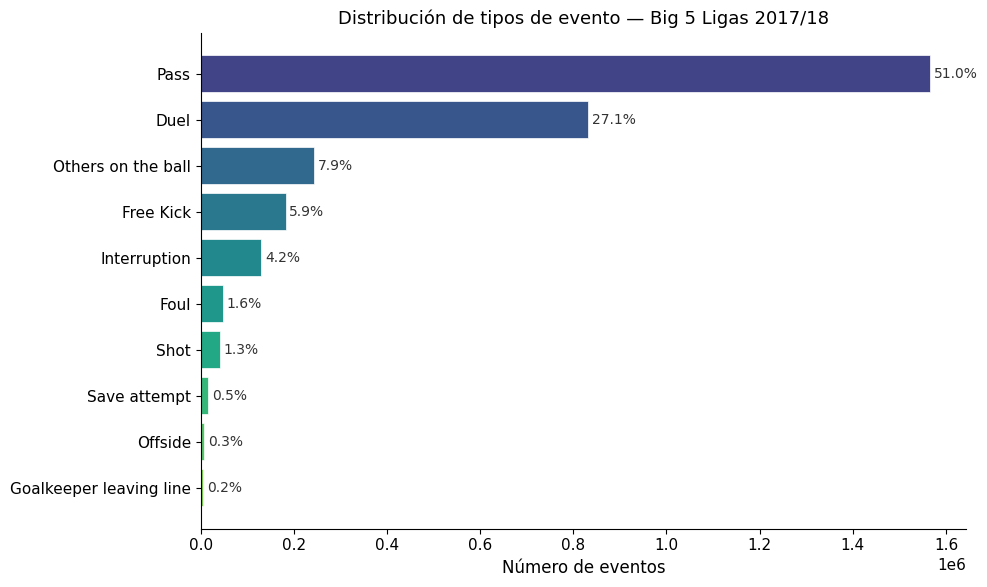


Los pases representan el 51.0% de todos los eventos,
consistente con Pappalardo et al. (2019): 'Passes are the most frequent event,
accounting for around 50% of the total events.'


In [8]:
# Distribución de tipos de evento
event_dist = df['event_name'].value_counts()
event_pct = (event_dist / event_dist.sum() * 100).round(1)

fig, ax = plt.subplots(figsize=(10, 6))
colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(event_dist)))
bars = ax.barh(event_dist.index[::-1], event_dist.values[::-1], color=colors[::-1],
               edgecolor='white', linewidth=0.5)

for bar, pct in zip(bars, event_pct.values[::-1]):
    ax.text(bar.get_width() + 8000, bar.get_y() + bar.get_height()/2,
            f'{pct}%', va='center', fontsize=10, color='#333333')

ax.set_xlabel('Número de eventos')
ax.set_title('Distribución de tipos de evento — Big 5 Ligas 2017/18', fontsize=13)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('figures/01_event_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nLos pases representan el {event_pct.get('Pass', 0):.1f}% de todos los eventos,")
print(f"consistente con Pappalardo et al. (2019): 'Passes are the most frequent event,")
print(f"accounting for around 50% of the total events.'")

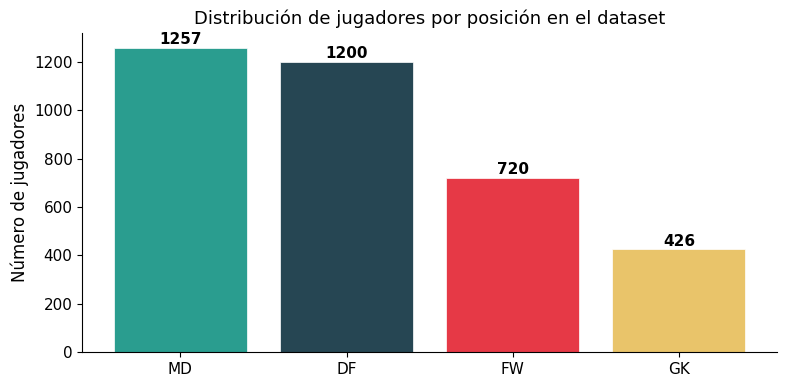


El dataset contiene 3,603 jugadores: 1257 mediocampistas, 1200 defensas, 720 delanteros, 426 porteros.


In [9]:
# Distribución de jugadores por posición en el dataset
pos_counts = players['position_code'].value_counts()

fig, ax = plt.subplots(figsize=(8, 4))
pos_colors = {'MD': '#2A9D8F', 'DF': '#264653', 'FW': '#E63946', 'GK': '#E9C46A'}
bars = ax.bar(pos_counts.index, pos_counts.values,
              color=[pos_colors.get(p, '#999') for p in pos_counts.index],
              edgecolor='white', linewidth=0.5)

for bar, val in zip(bars, pos_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 15,
            str(val), ha='center', fontsize=11, fontweight='bold')

ax.set_ylabel('Número de jugadores')
ax.set_title('Distribución de jugadores por posición en el dataset', fontsize=13)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('figures/01b_players_by_position.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nEl dataset contiene {len(players):,} jugadores: "
      f"{pos_counts.get('MD',0)} mediocampistas, {pos_counts.get('DF',0)} defensas, "
      f"{pos_counts.get('FW',0)} delanteros, {pos_counts.get('GK',0)} porteros.")

## 2. Calidad de los datos 

Antes de cualquier análisis, es imprescindible evaluar la fiabilidad del dataset.

En esta sección analizamos: valores nulos por variable, eventos sin jugador asignado,
distribución de minutos jugados (que determina el umbral de inclusión para el clustering),
y el tamaño muestral disponible por grupo posicional. Estas comprobaciones condicionan
directamente las decisiones de diseño de las fases posteriores.


### Análisis de datos nulos

In [10]:
# Análisis de valores nulos por columna
null_analysis = pd.DataFrame({
    'nulos': df.isnull().sum(),
    'pct_nulos': (df.isnull().sum() / len(df) * 100).round(2)
})
null_analysis = null_analysis[null_analysis['nulos'] > 0].sort_values('pct_nulos', ascending=False)

print("Valores nulos en el dataset")
print("=" * 55)
if len(null_analysis) == 0:
    print("No hay valores nulos en ninguna columna.")
else:
    print(null_analysis.to_string())

# Análisis específico: eventos sin jugador asignado
no_player = df[df['player_id'].isna()]
print(f"\n\nEventos sin jugador asignado: {len(no_player):,} ({len(no_player)/len(df)*100:.2f}%)")
print(f"Tipos de evento sin jugador:")
print(no_player['event_name'].value_counts().to_string())
print(f"\nEstos eventos corresponden a interrupciones del juego (balón fuera, pitidos)")
print(f"y no afectan al análisis de rendimiento individual.")

Valores nulos en el dataset
                              nulos  pct_nulos
body_part                   2969719      96.69
pass_distance_m             1506039      49.03
pass_goal_distance_delta_m  1506039      49.03
sub_event_id                   7821       0.25
sub_event_name                 7821       0.25
x_end_m                         709       0.02
y_end_m                         709       0.02


Eventos sin jugador asignado: 0 (0.00%)
Tipos de evento sin jugador:
Series([], )

Estos eventos corresponden a interrupciones del juego (balón fuera, pitidos)
y no afectan al análisis de rendimiento individual.


### Distribución de minutos jugados

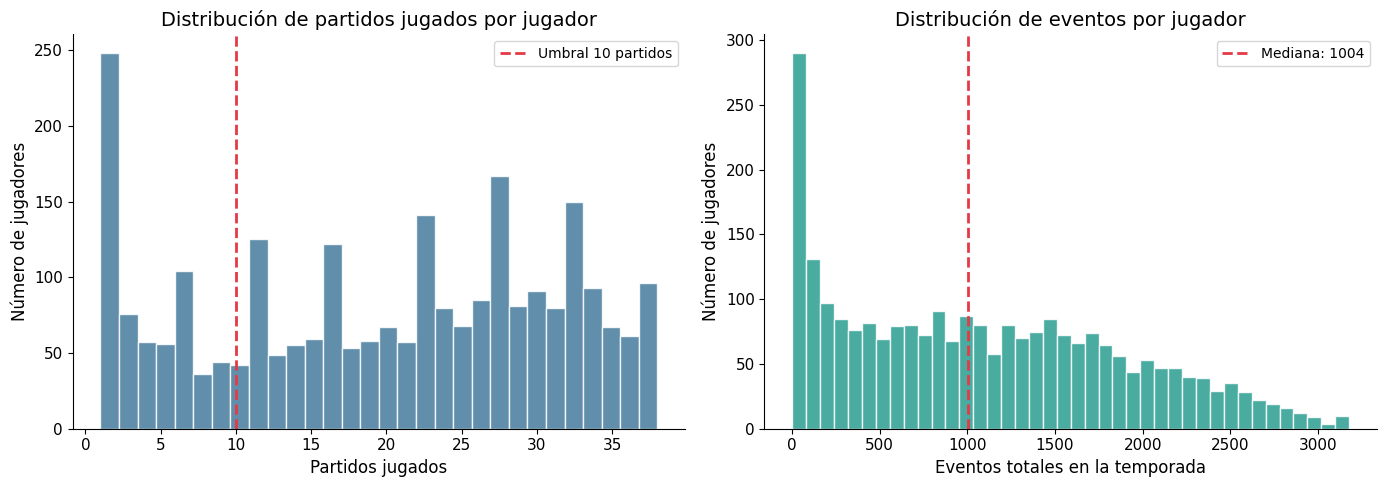

Jugadores con ≥10 partidos: 1947
Jugadores con <10 partidos: 621
Outliers (>40 partidos):    0


In [11]:
# Distribución de partidos y eventos por jugador
# Filtramos outliers extremos para visualización legible
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma de partidos jugados (acotado al rango razonable)
max_matches = player_summary_display['matches_played'].quantile(0.99)
data_matches = player_summary_display[player_summary_display['matches_played'] <= max_matches]['matches_played']

axes[0].hist(data_matches, bins=30, color='#457B9D', edgecolor='white', alpha=0.85)
axes[0].axvline(x=10, color='#E63946', linestyle='--', linewidth=2, label='Umbral 10 partidos')
axes[0].set_xlabel('Partidos jugados')
axes[0].set_ylabel('Número de jugadores')
axes[0].set_title('Distribución de partidos jugados por jugador')
axes[0].legend()
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# Histograma de eventos por jugador (acotado)
max_events = player_summary_display['total_events'].quantile(0.99)
data_events = player_summary_display[player_summary_display['total_events'] <= max_events]['total_events']

axes[1].hist(data_events, bins=40, color='#2A9D8F', edgecolor='white', alpha=0.85)
axes[1].axvline(x=data_events.median(), color='#E63946',
                linestyle='--', linewidth=2, label=f'Mediana: {data_events.median():.0f}')
axes[1].set_xlabel('Eventos totales en la temporada')
axes[1].set_ylabel('Número de jugadores')
axes[1].set_title('Distribución de eventos por jugador')
axes[1].legend()
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('figures/02_player_participation.png', dpi=150, bbox_inches='tight')
plt.show()

# Reportar outliers
outliers = player_summary_display[player_summary_display['matches_played'] > 40]
print(f"Jugadores con ≥10 partidos: {(player_summary_display['matches_played'] >= 10).sum()}")
print(f"Jugadores con <10 partidos: {(player_summary_display['matches_played'] < 10).sum()}")
print(f"Outliers (>40 partidos):    {len(outliers)}")
if len(outliers) > 0:
    print(f"\nJugadores con >40 partidos (posibles multi-liga o datos anómalos):")
    print(outliers.nlargest(10, 'matches_played')[['short_name', 'position_code', 'matches_played', 'total_events']].to_string(index=False))

### Viabilidad muestral por posición

In [12]:
# Viabilidad muestral: ¿hay suficientes jugadores por posición para clustering?
# Umbral estándar en la literatura: ≥900 minutos (~10 partidos completos)

MATCH_THRESHOLD = 10  # proxy de ~900 minutos

viable = player_summary_display[player_summary_display['matches_played'] >= MATCH_THRESHOLD].copy()
viable_by_pos = viable.groupby('position_code').agg(
    jugadores=('player_id', 'count'),
    partidos_medio=('matches_played', 'mean'),
    partidos_mediana=('matches_played', 'median'),
    eventos_medio=('total_events', 'mean'),
).round(1)

viable_by_pos = viable_by_pos.sort_values('jugadores', ascending=False)

print("Viabilidad muestral para clustering (jugadores con ≥10 partidos)")
print("=" * 70)
print(viable_by_pos.to_string())
print(f"\nTotal jugadores viables: {len(viable):,} de {len(player_summary_display):,} "
      f"({len(viable)/len(player_summary_display)*100:.1f}%)")

# Evaluación por grupo posicional para K-Means
POSITION_GROUPS = {'GK': 'Portero', 'DF': 'Defensa', 'MD': 'Mediocampista', 'FW': 'Delantero'}
viable['pos_group'] = viable['position_code'].map(POSITION_GROUPS)

group_counts = viable.groupby('pos_group')['player_id'].count().sort_values(ascending=False)
print(f"\nJugadores viables por grupo posicional:")
for group, count in group_counts.items():
    # Para K-Means con K=5, se recomienda mínimo ~50 observaciones por cluster
    min_k = count // 50  
    print(f"  {group:<15} {count:>4} jugadores → K-Means viable hasta K={min_k}")

print(f"\nConclusión: el tamaño muestral es suficiente para K-Means con K=4-7")
print(f"por grupo posicional, excepto porteros donde k debe adoptar valores bajos (2-4)")

Viabilidad muestral para clustering (jugadores con ≥10 partidos)
               jugadores  partidos_medio  partidos_mediana  eventos_medio
position_code                                                            
MD                   724            24.8              26.0         1478.2
DF                   662            23.7              24.0         1624.7
FW                   437            25.0              26.0         1088.3
GK                   124            28.0              31.0         1087.3

Total jugadores viables: 1,947 de 2,568 (75.8%)

Jugadores viables por grupo posicional:
  Mediocampista    724 jugadores → K-Means viable hasta K=14
  Defensa          662 jugadores → K-Means viable hasta K=13
  Delantero        437 jugadores → K-Means viable hasta K=8
  Portero          124 jugadores → K-Means viable hasta K=2

Conclusión: el tamaño muestral es suficiente para K-Means con K=4-7
por grupo posicional, excepto porteros donde k debe adoptar valores bajos (2-4)


### Conclusión sobre la calidad de los datos

#### Completitud de las variables

El dataset presenta una estructura de nulos coherente con la naturaleza de los datos de eventos futbolísticos:

| Variable | % Nulos | Interpretación |
|---|---|---|
| `body_part` | 96.7% | Variable condicional: solo se registra en tiros y pases con contacto explícito. El resto de eventos (duelos, faltas, intercepciones) no generan esta etiqueta. No constituye un dato faltante sino una variable de observación parcial. |
| `pass_distance_m` | 49.3% | Derivada exclusivamente para eventos de tipo `Pass`, que representan el ~48% del dataset. La coincidencia entre ambos porcentajes valida el cálculo realizado en la capa Silver. |
| `pass_goal_distance_delta_m` | 49.3% | Mismo caso que la variable `pass_distance_m`. 
| `x_end_m` / `y_end_m` | 0.02% | 709 eventos sin coordenada de destino sobre 3.071.295 — proporción despreciable (< 0.025%). |

**No se requiere imputación** en ninguna variable. Las variables analíticas clave
(coordenadas de origen, tipo de evento, resultado, jugador, equipo, partido) presentan
cobertura del 100% en el subconjunto de ligas de clubes.

#### Integridad referencial

Los conteos de eventos por competición coinciden exactamente con las cifras publicadas
por Pappalardo et al. (2019, Table 1), lo que confirma que el proceso ETL
(Bronze → Silver) no ha introducido pérdida ni duplicación de registros. Se detectan
0 eventos sin jugador asignado en las ligas de clubes; los 226.038 identificados en
la carga inicial correspondían a competiciones internacionales, excluidas del análisis
por la heterogeneidad de sus plantillas.

#### Distribución de participación y umbral de inclusión

La distribución de partidos por jugador presenta una marcada asimetría positiva,
con un gran volumen de jugadores con participación reducida (suplentes habituales,
cesiones a mitad de temporada, lesiones de larga duración). Se establece un umbral
mínimo de **≥10 partidos** como criterio de inclusión para las fases de agregación
y clustering.

Este umbral responde a dos criterios: 
    **1.** Estabilidad estadística de las métricas per90: con menos de ~900 minutos, las tasas por 90 minutos son altamente volátiles
y no representativas del rendimiento real del jugador.
    **2.** Alineación con la práctica estándar en la literatura de scouting basado en datos (Pappalardo et al., 2019; Webster, 2021).

#### Viabilidad muestral para el clustering

| Grupo posicional | n (≥10 partidos) | Partidos medio | Eventos medio |
|---|---|---|---|
| Mediocampista (MF) | 724 | 24.8 | 1.478 |
| Defensa (DF) | 662 | 23.7 | 1.625 |
| Delantero (FW) | 437 | 25.0 | 1.088 |
| Portero (GK) | 124 | 28.0 | 1.087 |
| **Total** | **1.947** (75.8%) | — | — |

El algoritmo K-Means busca minimizar la inercia intra-cluster, definida como la suma
de distancias cuadráticas de cada punto a su centroide. El número
óptimo de clusters K se determinará en la fase de clustering mediante la *Elbow Curve*
— representación gráfica de la inercia en función de K donde el cambio pronunciado
de pendiente indica el K más adecuado — complementada con el coeficiente
de silueta como métrica de cohesión-separación.

Una de las limitaciones de K-Means es que asume clusters con densidades y tamaños similares. 
Por tanto, los tamaños muestrales obtenidos (437-724 para jugadores de campo) proporcionan
un margen amplio para explorar valores de K entre 3 y 10, ya que incluso con K=10
cada cluster contendría en promedio ~44-72 observaciones en los grupos de campo.
El grupo de porteros (n=124) requiere un tratamiento diferenciado: por un lado, su
menor tamaño muestral limita el rango explorable de K; por otro, sus funciones
tácticas específicas demandan features distintas (paradas, salidas, distribución)
que no se comparten con jugadores de campo.

#### Decisiones derivadas para las fases posteriores

1. **Clustering por grupo posicional**, no global. Las diferencias funcionales y
   espaciales entre posiciones (verificadas en la Sección 4) hacen que un clustering
   global agrupe por posición, no por estilo — que es lo que buscamos identificar.
2. **Verificación de outliers** en la fase de agregación: los jugadores con >40
   partidos deben investigarse para descartar artefactos de participación en
   múltiples competiciones.
3. **Reducción de dimensionalidad mediante PCA** previa al clustering, para
   proyectar las ~80 features a un espacio de menor dimensión que preserve
   la estructura de varianza de los datos, eliminando multicolinealidad
   y mejorando la eficiencia del algoritmo.

## 3. Análisis temporal

Las acciones dentro de un partido se ven influenciadas por el momento en el que ocurre. 
El aumento de ocasiones, pérdidas de balón, verticalidad ofensiva, incluso el número de 
amonestaciones no presenta un patrón uniforme a lo largo del partido. Esta sección estudia 
cómo se distribuyen los eventos en el tiempo para identificar regularidades relevantes tanto para
la interpretación táctica como para las siguientes fases del proyecto.

En particular, este análisis permite:
- validar la coherencia temporal del dataset,
- detectar picos de actividad ofensiva y disciplinaria,
- estudiar si la conversión de tiro a gol varía a lo largo del partido,
- y conectar estos patrones con el futuro modelo xG y la construcción de
  features agregadas por jugador.


### 3.1 Preparación de la variable temporal

In [13]:
df_time = df[df['match_period'].isin(['1H', '2H'])].copy()

# Minuto continuo de partido
df_time['minute'] = df_time['event_sec'] / 60
df_time.loc[df_time['match_period'] == '2H', 'minute'] += 45

# Acotamos a 95 minutos para una visualización homogénea
df_time = df_time[df_time['minute'].between(0, 95)].copy()

# Minuto entero
df_time['minute_int'] = np.floor(df_time['minute']).astype(int)

# Tramos interpretables
time_bins = [0, 15, 30, 45, 60, 75, 90, 95]
time_labels = ['0-15', '16-30', '31-45', '46-60', '61-75', '76-90', '90+']

df_time['time_bin'] = pd.cut(
    df_time['minute'],
    bins=time_bins,
    labels=time_labels,
    include_lowest=True,
    right=True
)

print("Variable temporal construida")
print(f"Eventos analizados: {len(df_time):,}")
print(f"Partidos: {df_time['match_id'].nunique():,}")
print(f"Rango temporal: {df_time['minute'].min():.2f} - {df_time['minute'].max():.2f} min")

Variable temporal construida
Eventos analizados: 3,067,102
Partidos: 1,826
Rango temporal: 0.00 - 95.00 min


### 3.2 Distribución general de eventos

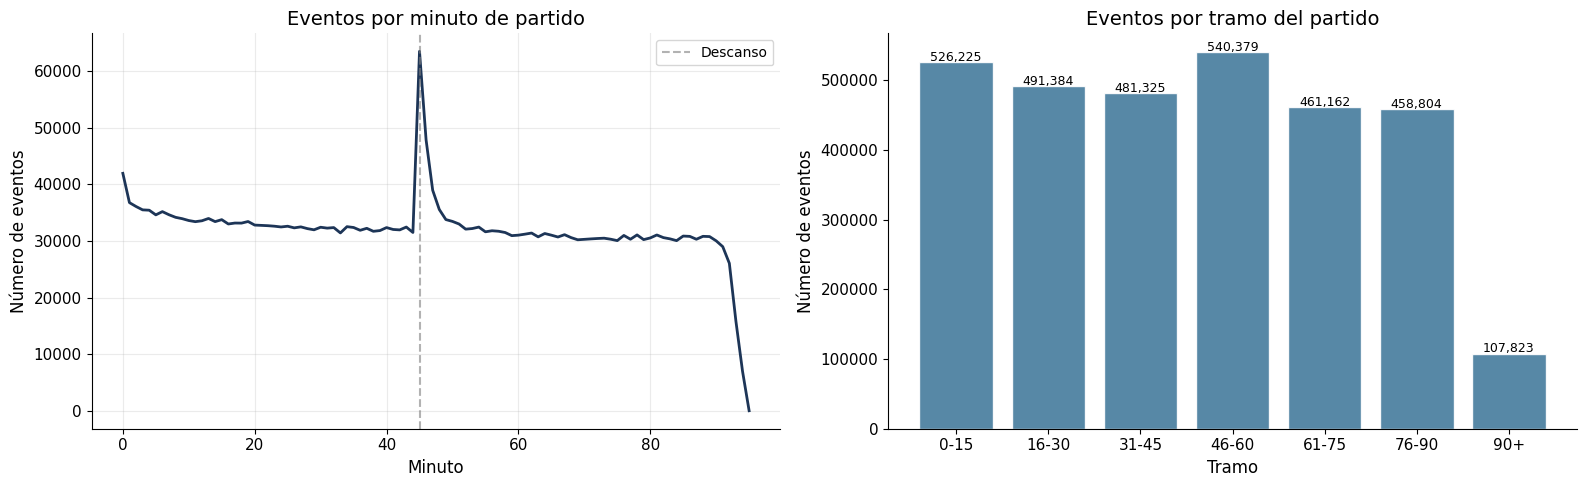

La distribución temporal total permite comprobar la coherencia del registro
   y detectar si existen cambios de intensidad entre la primera y la segunda parte.


In [14]:
events_per_minute = (
    df_time.groupby('minute_int')
    .size()
    .reindex(range(96), fill_value=0)
    .reset_index(name='n_events')
)

events_by_bin = (
    df_time.groupby('time_bin', observed=False)
    .size()
    .reset_index(name='n_events')
)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Serie por minuto
axes[0].plot(events_per_minute['minute_int'], events_per_minute['n_events'],
             color='#1D3557', linewidth=2)
axes[0].axvline(x=45, color='gray', linestyle='--', alpha=0.6, label='Descanso')
axes[0].set_title('Eventos por minuto de partido')
axes[0].set_xlabel('Minuto')
axes[0].set_ylabel('Número de eventos')
axes[0].legend()
axes[0].grid(alpha=0.25)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# Barras por tramo
bars = axes[1].bar(events_by_bin['time_bin'].astype(str), events_by_bin['n_events'],
                   color='#457B9D', edgecolor='white', alpha=0.9)

for bar, val in zip(bars, events_by_bin['n_events']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2000,
                 f'{val:,}', ha='center', fontsize=9)

axes[1].set_title('Eventos por tramo del partido')
axes[1].set_xlabel('Tramo')
axes[1].set_ylabel('Número de eventos')
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('figures/02_temporal_events_overview.png', dpi=150, bbox_inches='tight')
plt.show()


print("La distribución temporal total permite comprobar la coherencia del registro")
print("   y detectar si existen cambios de intensidad entre la primera y la segunda parte.")

### 3.3 Tiros, goles y tarjetas amarillas

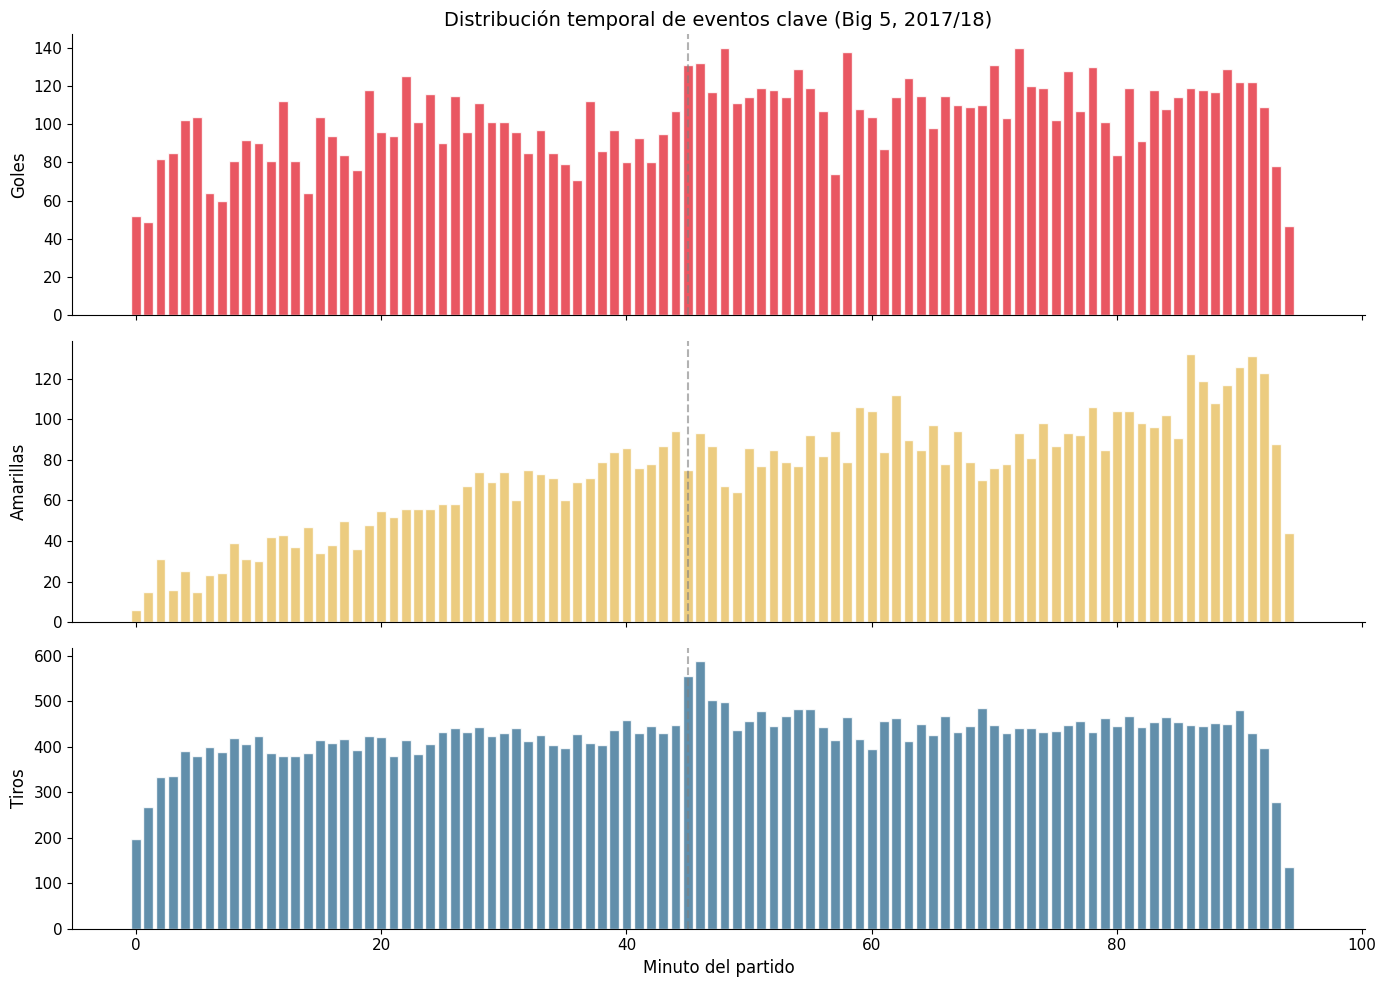

Resumen temporal por tramo
time_bin  total_events  shots  goals  yellow_cards  shot_goals  shot_conversion_pct  shots_per_1000_events
    0-15        526225   5474   1199           424         542                 9.90                  10.40
   16-30        491384   6241   1521           807         662                10.61                  12.70
   31-45        481325   6405   1364          1137         596                 9.31                  13.31
   46-60        540379   7144   1771          1243         776                10.86                  13.22
   61-75        461162   6631   1699          1319         757                11.42                  14.38
   76-90        458804   6765   1685          1534         728                10.76                  14.74
     90+        107823   1722    478           512         202                11.73                  15.97

 Goles totales: 9,717
 Tiros totales: 40,382
 Amarillas totales: 6,976

 El pico en el minuto 45 se debe a la acumul

In [15]:
shots = df_time[df_time['event_name'] == 'Shot'].copy()
goals = df_time[df_time['is_goal'] == True].copy()
yellows = df_time[df_time['is_yellow_card'] == True].copy()

shots_per_min = (
    shots.groupby('minute_int')
    .size()
    .reindex(range(96), fill_value=0)
    .reset_index(name='shots')
)

goals_per_min = (
    goals.groupby('minute_int')
    .size()
    .reindex(range(96), fill_value=0)
    .reset_index(name='goals')
)

yellows_per_min = (
    yellows.groupby('minute_int')
    .size()
    .reindex(range(96), fill_value=0)
    .reset_index(name='yellow_cards')
)

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

axes[0].bar(goals_per_min['minute_int'], goals_per_min['goals'],
            color='#E63946', edgecolor='white', alpha=0.85)
axes[0].axvline(x=45, color='gray', linestyle='--', alpha=0.6)
axes[0].set_ylabel('Goles')
axes[0].set_title('Distribución temporal de eventos clave (Big 5, 2017/18)')
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

axes[1].bar(yellows_per_min['minute_int'], yellows_per_min['yellow_cards'],
            color='#E9C46A', edgecolor='white', alpha=0.85)
axes[1].axvline(x=45, color='gray', linestyle='--', alpha=0.6)
axes[1].set_ylabel('Amarillas')
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

axes[2].bar(shots_per_min['minute_int'], shots_per_min['shots'],
            color='#457B9D', edgecolor='white', alpha=0.85)
axes[2].axvline(x=45, color='gray', linestyle='--', alpha=0.6)
axes[2].set_ylabel('Tiros')
axes[2].set_xlabel('Minuto del partido')
axes[2].spines['top'].set_visible(False)
axes[2].spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('figures/02_temporal_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

temporal_summary = (
    df_time.groupby('time_bin', observed=False)
    .agg(
        total_events=('wy_event_id', 'count'),
        shots=('event_name', lambda x: (x == 'Shot').sum()),
        goals=('is_goal', 'sum'),
        yellow_cards=('is_yellow_card', 'sum')
    )
    .reset_index()
)

# Conversión real: goles DESDE tiros / tiros totales
shot_goals_by_bin = (
    shots[shots['is_goal'] == True]
    .groupby('time_bin', observed=False)
    .size()
    .reindex(time_labels, fill_value=0)
    .reset_index(name='shot_goals')
)

temporal_summary = temporal_summary.merge(shot_goals_by_bin, on='time_bin', how='left')
temporal_summary['shot_conversion_pct'] = (
    temporal_summary['shot_goals'] / temporal_summary['shots'] * 100
).round(2)

temporal_summary['shots_per_1000_events'] = (
    temporal_summary['shots'] / temporal_summary['total_events'] * 1000
).round(2)

print("Resumen temporal por tramo")
print("=" * 80)
print(temporal_summary.to_string(index=False))

print(f"\n Goles totales: {len(goals):,}")
print(f" Tiros totales: {len(shots):,}")
print(f" Amarillas totales: {len(yellows):,}")

print("\n El pico en el minuto 45 se debe a la acumulación de eventos del tiempo de descuento")
print("  de la primera parte, que Wyscout registra con event_sec cercanos al final del periodo.")

### 3.4 Primera parte vs segunda parte

In [16]:
match_period_summary = (
    df_time.assign(period_group=np.where(df_time['minute'] < 45, '1ª parte', '2ª parte'))
    .groupby(['match_id', 'period_group'])
    .agg(
        events=('wy_event_id', 'count'),
        shots=('event_name', lambda x: (x == 'Shot').sum()),
        goals=('is_goal', 'sum'),
        yellow_cards=('is_yellow_card', 'sum')
    )
    .reset_index()
)

pivot_summary = match_period_summary.pivot(index='match_id', columns='period_group')
pivot_summary.columns = ['_'.join(col) for col in pivot_summary.columns]
pivot_summary = pivot_summary.dropna()

print("Comparación 1ª vs 2ª parte (promedio por partido)")
print("=" * 60)
for metric in ['events', 'shots', 'goals', 'yellow_cards']:
    first = pivot_summary[f'{metric}_1ª parte']
    second = pivot_summary[f'{metric}_2ª parte']
    print(f"{metric:<15} 1ª parte = {first.mean():6.2f} | 2ª parte = {second.mean():6.2f}")

# Test no paramétrico simple
print("\nTest de Wilcoxon pareado por partido")
print("=" * 60)
for metric in ['events', 'shots', 'goals', 'yellow_cards']:
    first = pivot_summary[f'{metric}_1ª parte']
    second = pivot_summary[f'{metric}_2ª parte']
    stat, p = stats.wilcoxon(first, second)
    print(f"{metric:<15} estadístico = {stat:10.2f} | p-valor = {p:.4g}")

Comparación 1ª vs 2ª parte (promedio por partido)
events          1ª parte = 820.88 | 2ª parte = 858.80
shots           1ª parte =   9.92 | 2ª parte =  12.19
goals           1ª parte =   2.24 | 2ª parte =   3.08
yellow_cards    1ª parte =   1.30 | 2ª parte =   2.52

Test de Wilcoxon pareado por partido
events          estadístico =  419288.50 | p-valor = 8.087e-74
shots           estadístico =  344092.50 | p-valor = 3.515e-77
goals           estadístico =  304931.00 | p-valor = 2.813e-31
yellow_cards    estadístico =  195021.50 | p-valor = 2.217e-110


### 3.5 Conversión de tiro a gol por tramo

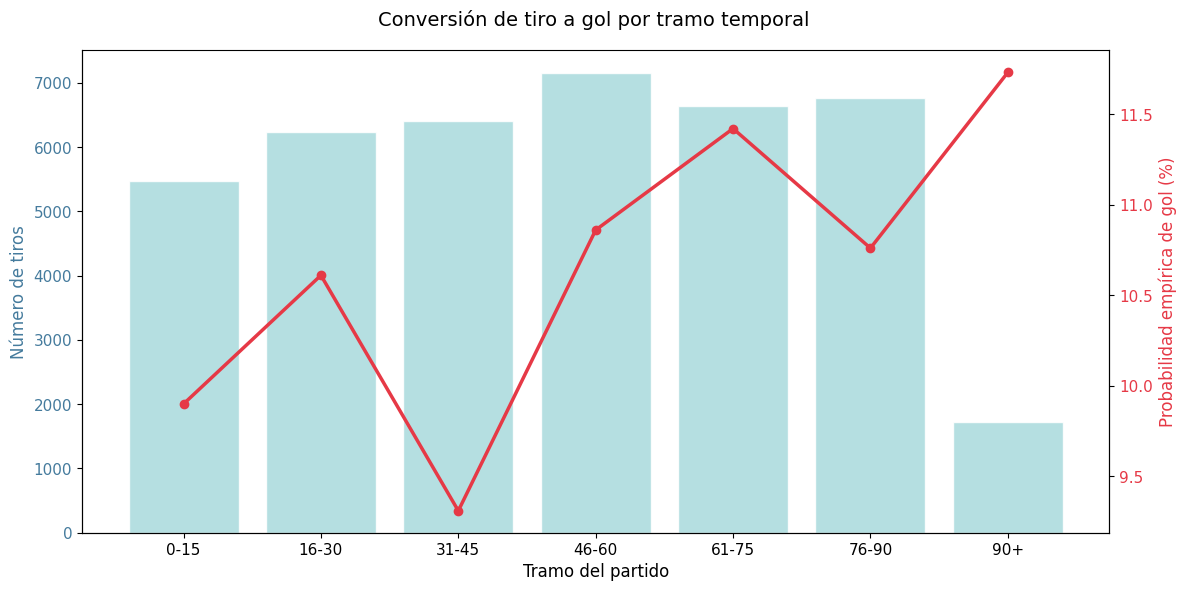

Conversión de tiro a gol por tramo
time_bin  shots  goals  conversion_pct
    0-15   5474    542            9.90
   16-30   6241    662           10.61
   31-45   6405    596            9.31
   46-60   7144    776           10.86
   61-75   6631    757           11.42
   76-90   6765    728           10.76
     90+   1722    202           11.73

 Tramo con mayor conversión: 90+
 Tramo con menor conversión: 31-45
   Esto ayuda a distinguir entre mayor volumen ofensivo y mayor eficacia real.


In [17]:
shot_conversion = (
    shots.groupby('time_bin', observed=False)
    .agg(
        shots=('wy_event_id', 'count'),
        goals=('is_goal', 'sum')
    )
    .reset_index()
)

shot_conversion['conversion_pct'] = (
    shot_conversion['goals'] / shot_conversion['shots'] * 100
).round(2)

fig, ax1 = plt.subplots(figsize=(12, 6))

bars = ax1.bar(shot_conversion['time_bin'].astype(str), shot_conversion['shots'],
               color='#A8DADC', edgecolor='white', alpha=0.85, label='Tiros')
ax1.set_xlabel('Tramo del partido')
ax1.set_ylabel('Número de tiros', color='#457B9D')
ax1.tick_params(axis='y', labelcolor='#457B9D')
ax1.spines['top'].set_visible(False)

ax2 = ax1.twinx()
ax2.plot(shot_conversion['time_bin'].astype(str), shot_conversion['conversion_pct'],
         color='#E63946', marker='o', linewidth=2.5, label='Conversión')
ax2.set_ylabel('Probabilidad empírica de gol (%)', color='#E63946')
ax2.tick_params(axis='y', labelcolor='#E63946')

fig.suptitle('Conversión de tiro a gol por tramo temporal', fontsize=14)

plt.tight_layout()
plt.savefig('figures/02b_shot_conversion_by_time.png', dpi=150, bbox_inches='tight')
plt.show()

print("Conversión de tiro a gol por tramo")
print("=" * 60)
print(shot_conversion.to_string(index=False))

best_bin = shot_conversion.loc[shot_conversion['conversion_pct'].idxmax(), 'time_bin']
worst_bin = shot_conversion.loc[shot_conversion['conversion_pct'].idxmin(), 'time_bin']

print(f"\n Tramo con mayor conversión: {best_bin}")
print(f" Tramo con menor conversión: {worst_bin}")
print("   Esto ayuda a distinguir entre mayor volumen ofensivo y mayor eficacia real.")

### 3.6 Patrones temporales por liga

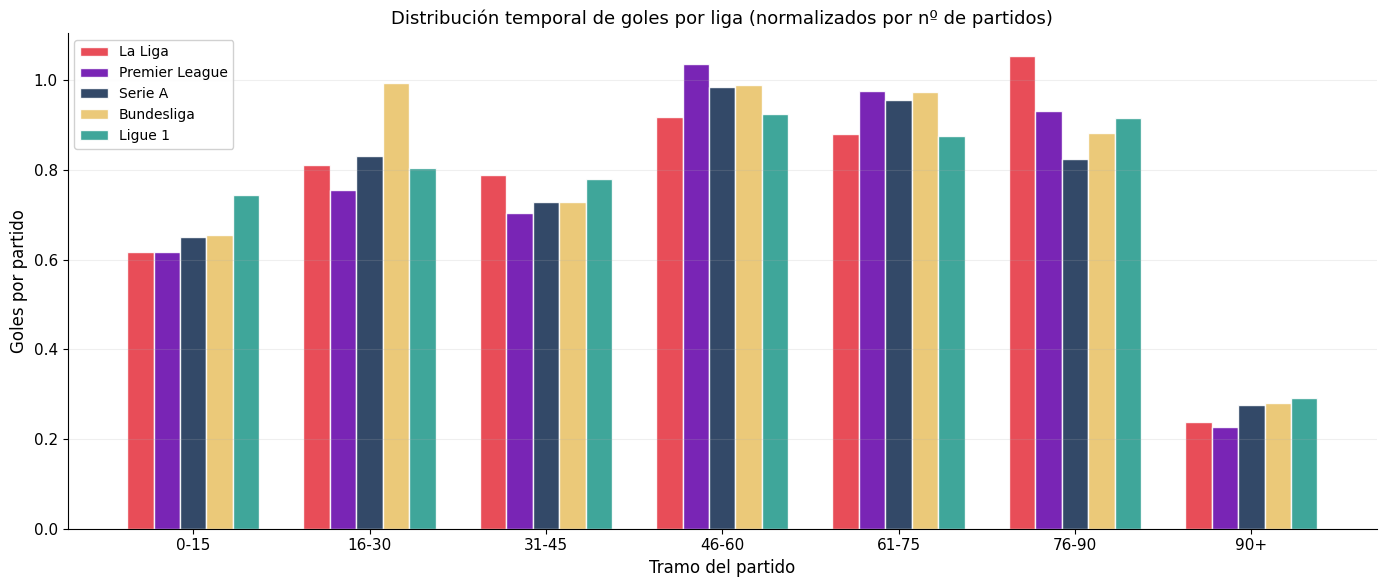


Test χ² de independencia (liga × tramo temporal de goles)
   χ² = 43.20, gl = 24, p-valor = 0.009425
   → Se rechaza H₀: existen diferencias significativas entre ligas.


In [18]:
# Goles por tramo y liga (normalizado por partido)
goals_league = (
    df_time[df_time['is_goal'] == True]
    .groupby(['league', 'time_bin'], observed=False)
    .size()
    .reset_index(name='goals')
)

matches_per_league = df_time.groupby('league')['match_id'].nunique().reset_index(name='n_matches')
goals_league = goals_league.merge(matches_per_league, on='league')
goals_league['goals_per_match'] = (goals_league['goals'] / goals_league['n_matches']).round(3)

fig, ax = plt.subplots(figsize=(14, 6))

x = np.arange(len(time_labels))
width = 0.15
league_list = ['La Liga', 'Premier League', 'Serie A', 'Bundesliga', 'Ligue 1']

SHORT_TO_FULL = {v: k for k, v in LEAGUE_SHORT.items()}

for i, league in enumerate(league_list):
    data = goals_league[goals_league['league'] == league].sort_values('time_bin')
    ax.bar(x + i * width, data['goals_per_match'], width,
           color=LEAGUE_COLORS[SHORT_TO_FULL[league]], label=league,
           edgecolor='white', alpha=0.9)

ax.set_xlabel('Tramo del partido')
ax.set_ylabel('Goles por partido')
ax.set_title('Distribución temporal de goles por liga (normalizados por nº de partidos)', fontsize=13)
ax.set_xticks(x + width * 2)
ax.set_xticklabels(time_labels)
ax.legend(loc='upper left', framealpha=0.9)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', alpha=0.2)

plt.tight_layout()
plt.savefig('figures/03_goals_by_time_and_league.png', dpi=150, bbox_inches='tight')
plt.show()

# Test estadístico: ¿las ligas difieren en distribución temporal de goles?
from scipy.stats import chi2_contingency

contingency = (
    df_time[df_time['is_goal'] == True]
    .groupby(['league', 'time_bin'], observed=False)
    .size()
    .unstack(fill_value=0)
)

chi2, p_val, dof, expected = chi2_contingency(contingency)
print(f"\nTest χ² de independencia (liga × tramo temporal de goles)")
print(f"   χ² = {chi2:.2f}, gl = {dof}, p-valor = {p_val:.4g}")
if p_val > 0.05:
    print("   → No se rechaza H₀: la distribución temporal de goles es homogénea entre ligas.")
else:
    print("   → Se rechaza H₀: existen diferencias significativas entre ligas.")

### Conclusión del análisis temporal

El análisis temporal de los 3.067.102 eventos en tiempo reglamentario revela tres 
patrones estructurales consistentes con la literatura sobre dinámica de partidos:

**1. Asimetría significativa entre partes.**
La segunda parte presenta una mayor intensidad ofensiva y disciplinaria que la primera. En promedio por partido, los tiros aumentan un 23% (12.19 vs 9.92), los goles un 38% (3.08 vs 2.24) y las tarjetas amarillas un 94% (2.52 vs 1.30).

Para contrastar si estas diferencias eran estadísticamente significativas, se utilizó el test de Wilcoxon para muestras pareadas, un método no paramétrico adecuado para comparar dos mediciones relacionadas sin asumir normalidad en los datos. En este caso, el test compara las métricas registradas en la primera y la segunda parte de cada partido, evaluando si las diferencias observadas siguen una tendencia sistemática y no atribuible al azar.

Las diferencias fueron contrastadas sobre un total de 1.826 partidos, obteniéndose p-valores inferiores a 10⁻³⁰ en todas las métricas analizadas, lo que indica diferencias estadísticamente significativas entre ambas mitades. Este patrón es consistente con factores descritos en la literatura futbolística, como el aumento del riesgo táctico en fases finales del partido, la fatiga acumulada y el incremento de interrupciones y acciones defensivas cuando el resultado permanece abierto.

**2. Distinción entre volumen ofensivo y eficacia.**
La tasa de conversión de tiro a gol oscila entre el 9.3% (minutos 31-45) y el 11.4% 
(minutos 61-75) en los tramos regulares, una variación modesta que indica que el minuto 
del partido, por sí solo, tiene una influencia limitada sobre la probabilidad de gol. 
El tramo 90+ presenta la conversión más alta (11.7%), si bien este dato debe interpretarse 
con cautela, lo exploraremos en las siguientes fases. En este caso, el tramo +90, tiene mayor 
probabilidad de gol al ser el tramo con menos disparos, 1722. Esta observación anticipa un resultado clave para el 
modelo xG: las variables espaciales (distancia, ángulo) serán predictores más potentes 
que el contexto temporal. 

**3. Diferencias significativas entre ligas.**
El test χ² de independencia (liga × tramo temporal) arroja χ² = 43.20 (gl = 24, 
p = 0.009), lo que permite rechazar la hipótesis de homogeneidad temporal entre las 
cinco ligas. La inspección visual del gráfico normalizado sugiere que las diferencias 
principales se concentran en los tramos finales: La Liga destaca con un pico de ~1.04 
goles/partido en los minutos 76-90, mientras que la Bundesliga concentra mayor producción 
ofensiva en el tramo 16-30 (~1.0 goles/partido). Ligue 1 muestra la distribución más 
uniforme. Aunque estadísticamente significativas, estas diferencias son de magnitud 
pequeña y no justifican un tratamiento temporal diferenciado por liga en el modelo.

### Implicaciones para las fases posteriores

- **Modelo xG:** Se incluirá `minute_match` como feature candidata, pero se espera que 
  su importancia sea baja frente a distancia y ángulo. El análisis confirma que la 
  conversión de tiro no depende fuertemente del momento del partido.

- **Feature engineering por jugador:** La asimetría 1H/2H sugiere que features como 
  *participación ofensiva en los últimos 15 minutos* o *ratio de faltas en tramos finales* 
  podrían capturar perfiles de jugador diferenciados (jugadores capaces de resolver partidos), enriqueciendo el clustering de estilos.

- **Normalización per90:** La distribución esencialmente estable del volumen de eventos
  a lo largo del partido confirma que la normalización per90 es adecuada como métrica
  de intensidad. No obstante, para jugadores sustituidos sistemáticamente antes del
  minuto 70, las métricas per90 extrapolan su rendimiento parcial a 90 minutos completos,
  lo que puede introducir volatilidad en jugadores con pocos minutos. El umbral de ≥10
  partidos establecido en la sección 2 mitiga este efecto.

#### Nota técnica

El pico observado en el minuto 45 del gráfico de eventos por minuto (celda 3.2) se debe 
a la acumulación de eventos del tiempo de descuento de la primera parte: Wyscout registra 
estos eventos con valores de `event_sec` cercanos al final del periodo, generando una 
concentración artificial que no refleja un aumento real de la intensidad de juego.

## 4. Análisis espacial

Las coordenadas Wyscout, transformadas a metros reales (105×68 m) en la capa Silver,
permiten estudiar la distribución espacial de las acciones en el campo. Este análisis
es fundamental para el proyecto por dos razones: primero, las variables espaciales
(`dist_to_goal_m`, `angle_to_goal_deg`, `zone_x`, `zone_y`) serán los predictores
principales del modelo xG; segundo, las diferencias espaciales por posición y liga
servirán para la selección de features para el clustering de estilos de juego.

Esta sección cubre:
- Distribución general de eventos en el campo (heatmap de densidad)
- Heatmaps por tipo de evento (tiros, pases, duelos, faltas)
- Precisión de pase por zona del campo (grid 12×8)
- Centro de gravedad ofensivo por liga


### 4.1 Preparación de datos espaciales

In [19]:
# Trabajamos sobre df (ya filtrado a Big 5 en la carga inicial)
# Excluimos prórroga y penaltis para reflejar el juego en 90 minutos
df_spatial = df[
    (df['x_m'].notna()) &
    (df['is_extra_time'] == False) &
    (df['is_penalties'] == False)
].copy()

print(f"Eventos con coordenadas (tiempo reglamentario): {len(df_spatial):,}")
print(f"Partidos: {df_spatial['match_id'].nunique():,}")
print(f"\nRango espacial:")
print(f"  x_m: {df_spatial['x_m'].min():.1f} — {df_spatial['x_m'].max():.1f} m (largo)")
print(f"  y_m: {df_spatial['y_m'].min():.1f} — {df_spatial['y_m'].max():.1f} m (ancho)")
print(f"\nEventos por tipo:")
print(df_spatial['event_name'].value_counts().to_string())

Eventos con coordenadas (tiempo reglamentario): 3,071,395
Partidos: 1,826

Rango espacial:
  x_m: -1.1 — 105.0 m (largo)
  y_m: 0.0 — 68.7 m (ancho)

Eventos por tipo:
event_name
Pass                       1565356
Duel                        832055
Others on the ball          242837
Free Kick                   182468
Interruption                130096
Foul                         47955
Shot                         40461
Save attempt                 16567
Offside                       7821
Goalkeeper leaving line       5779


El rango de x_m (-1.1 a 105.0) indica que un número marginal de eventos se registra ligeramente fuera de los límites del campo, probablemente debido a la resolución de la captura de Wyscout. Estos valores representan < 0.01% del dataset y no afectan al análisis.

### 4.2 Heatmap general de densidad de eventos

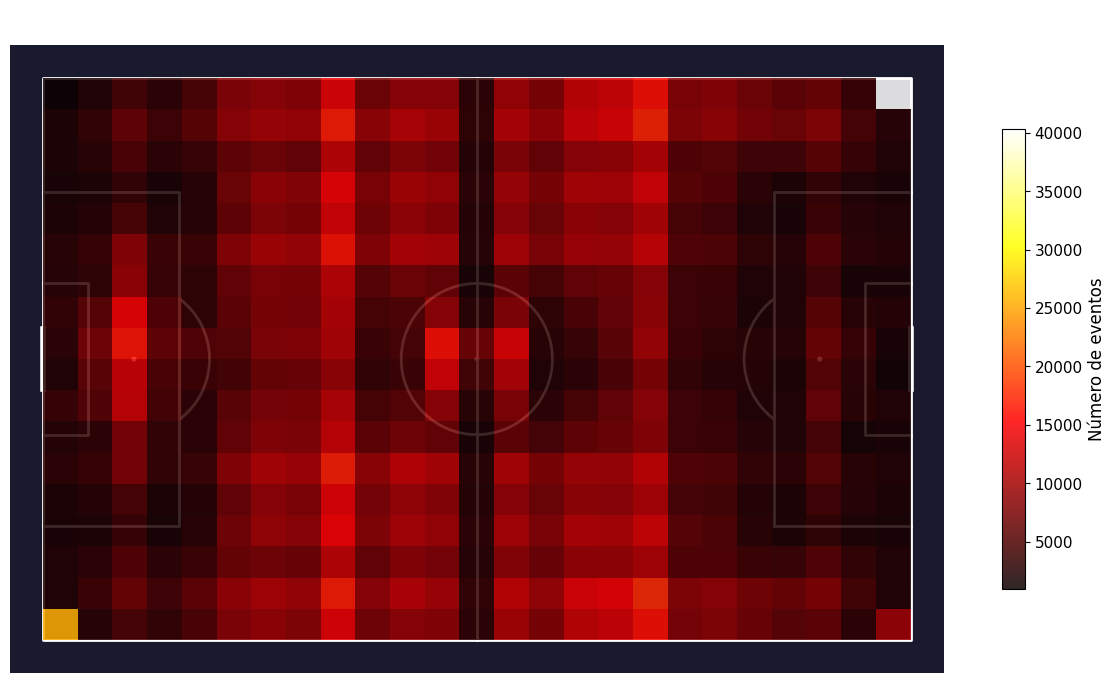

In [20]:
fig, ax = plt.subplots(figsize=(12, 8))
pitch = Pitch(pitch_type='custom', pitch_length=105, pitch_width=68,
              line_color='white', pitch_color='#1a1a2e')
pitch.draw(ax=ax)

bin_stats = pitch.bin_statistic(
    df_spatial['x_m'], df_spatial['y_m'],
    statistic='count', bins=(25, 18)
)
pcm = pitch.heatmap(bin_stats, ax=ax, cmap='hot', edgecolors='none', alpha=0.85)
fig.colorbar(pcm, ax=ax, shrink=0.6, label='Número de eventos')

ax.set_title('Densidad espacial — primera inspección (sin correcciones)',
             fontsize=13, color='white', pad=15)

plt.tight_layout()
plt.savefig('figures/04a_heatmap_raw.png', dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()

#### Detección de artefacto espacial

La primera inspección visual revela focos de alta densidad en las cuatro esquinas del campo
y en las líneas de banda (bordes superior e inferior). Este patrón no es tácticamente
plausible, las esquinas del campo no son zonas de alta actividad en el juego regular.

Esto sugiere un artefacto del proceso de etiquetado de Wyscout. Antes de proceder con
el análisis espacial, es necesario **diagnosticar** y **cuantificar** este fenómeno para
decidir qué tratamiento aplicar.

In [21]:
# Eventos en las esquinas exactas (margen de 1 metro)
CORNER_MARGIN = 1.0

corners = df_spatial[
    ((df_spatial['x_m'] <= CORNER_MARGIN) & (df_spatial['y_m'] <= CORNER_MARGIN)) |
    ((df_spatial['x_m'] <= CORNER_MARGIN) & (df_spatial['y_m'] >= 68 - CORNER_MARGIN)) |
    ((df_spatial['x_m'] >= 105 - CORNER_MARGIN) & (df_spatial['y_m'] <= CORNER_MARGIN)) |
    ((df_spatial['x_m'] >= 105 - CORNER_MARGIN) & (df_spatial['y_m'] >= 68 - CORNER_MARGIN))
]

print("1. ARTEFACTO DE ESQUINAS")
print(f"   Eventos en esquinas (margen {CORNER_MARGIN}m): {len(corners):,} "
      f"({len(corners)/len(df_spatial)*100:.2f}%)")
print(f"\n   Desglose por tipo de evento:")
print(corners['event_name'].value_counts().head(10).to_string())

# Acumulación en líneas de banda
banda_inf = df_spatial[df_spatial['y_m'] < 0.5]
banda_sup = df_spatial[df_spatial['y_m'] > 67.5]

print(f"\n2. ACUMULACIÓN EN LÍNEAS DE BANDA")
print(f"   Eventos con y_m < 0.5m: {len(banda_inf):,}")
print(f"   Eventos con y_m > 67.5m: {len(banda_sup):,}")
print(f"   Total en bandas: {len(banda_inf) + len(banda_sup):,} "
      f"({(len(banda_inf) + len(banda_sup))/len(df_spatial)*100:.1f}%)")

# Asimetría vertical (¿sesgo de normalización?)
upper = df_spatial[df_spatial['y_m'] > 34].shape[0]
lower = df_spatial[df_spatial['y_m'] <= 34].shape[0]

print(f"\n3. SIMETRÍA VERTICAL")
print(f"   Mitad superior (y > 34m): {upper:,} ({upper/len(df_spatial)*100:.1f}%)")
print(f"   Mitad inferior (y ≤ 34m): {lower:,} ({lower/len(df_spatial)*100:.1f}%)")
print(f"   Ratio: {upper/lower:.3f} (1.000 = perfecta simetría)")

# Eventos fuera de los límites del campo
out_of_bounds = df_spatial[
    (df_spatial['x_m'] < 0) | (df_spatial['x_m'] > 105) |
    (df_spatial['y_m'] < 0) | (df_spatial['y_m'] > 68)
]
print(f"\n4. EVENTOS FUERA DE LÍMITES")
print(f"   Fuera de 0-105m (x) o 0-68m (y): {len(out_of_bounds):,} "
      f"({len(out_of_bounds)/len(df_spatial)*100:.3f}%)")

1. ARTEFACTO DE ESQUINAS
   Eventos en esquinas (margen 1.0m): 70,975 (2.31%)

   Desglose por tipo de evento:
event_name
Free Kick                  47243
Save attempt               16567
Goalkeeper leaving line     5779
Interruption                1378
Duel                           4
Others on the ball             4

2. ACUMULACIÓN EN LÍNEAS DE BANDA
   Eventos con y_m < 0.5m: 112,698
   Eventos con y_m > 67.5m: 120,292
   Total en bandas: 232,990 (7.6%)

3. SIMETRÍA VERTICAL
   Mitad superior (y > 34m): 1,518,630 (49.4%)
   Mitad inferior (y ≤ 34m): 1,552,765 (50.6%)
   Ratio: 0.978 (1.000 = perfecta simetría)

4. EVENTOS FUERA DE LÍMITES
   Fuera de 0-105m (x) o 0-68m (y): 2 (0.000%)


El análisis revela tres fenómenos en las coordenadas del dataset Wyscout:

**1. Artefacto de esquinas (~2.3% de eventos).**
Wyscout registra los saques de esquina en las coordenadas literales del córner (0,0),
(0,68), (105,0), (105,68). Además, ciertos eventos sin posición precisa (interrupciones,
algunos saques de meta) reciben coordenadas por defecto en los extremos del campo. Este
fenómeno es un artefacto conocido del proceso de etiquetado y no refleja actividad táctica
real.

**2. Acumulación en líneas de banda (~7.6%).**
Se detectan ~233.000 eventos concentrados en franjas estrechas junto a las líneas de banda
(y < 0.5m e y > 67.5m). A diferencia de las esquinas, estos eventos son posicionalmente
correctos — los saques de banda, faltas laterales y ciertos regates por banda ocurren
efectivamente en la línea. Se mantienen en el análisis pero se documenta su efecto visual
en los heatmaps.

**3. Simetría vertical confirmada (ratio 0.978).**
La distribución entre la mitad superior e inferior del campo es prácticamente simétrica,
lo que confirma que la normalización de coordenadas de Wyscout (atacando siempre hacia
x=100) no introduce sesgos laterales.

**Decisión de tratamiento:** Se excluyen los eventos de esquina (margen de 1m) de las
visualizaciones de densidad para evitar distorsión. Los eventos de banda se mantienen.
Los eventos fuera de límites son marginales y se filtran en `df_spatial` (x_m ≥ 0). Este
filtrado afecta solo a la visualización; los datos originales se preservan íntegros en
Silver para las fases de modelado, donde se utilizan variables derivadas (distancia, ángulo)
en lugar de coordenadas crudas.

Eventos excluidos por artefacto de esquinas (margen 1.0m): 70,975 (2.31%)


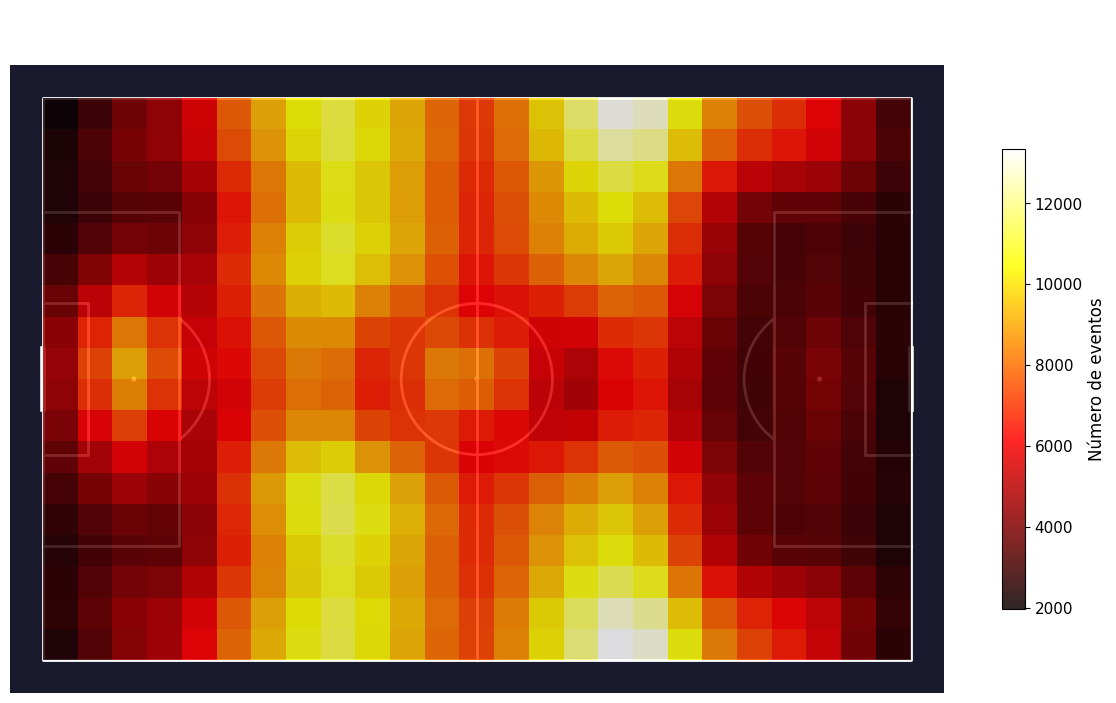

In [22]:
# Filtrar artefactos de coordenadas en esquinas exactas (0,0), (0,68), (105,0), (105,68)
CORNER_MARGIN = 1.0  # metros
df_heatmap = df_spatial[
    ~(
        ((df_spatial['x_m'] <= CORNER_MARGIN) & (df_spatial['y_m'] <= CORNER_MARGIN)) |
        ((df_spatial['x_m'] <= CORNER_MARGIN) & (df_spatial['y_m'] >= 68 - CORNER_MARGIN)) |
        ((df_spatial['x_m'] >= 105 - CORNER_MARGIN) & (df_spatial['y_m'] <= CORNER_MARGIN)) |
        ((df_spatial['x_m'] >= 105 - CORNER_MARGIN) & (df_spatial['y_m'] >= 68 - CORNER_MARGIN))
    )
].copy()

excluded = len(df_spatial) - len(df_heatmap)
print(f"Eventos excluidos por artefacto de esquinas (margen {CORNER_MARGIN}m): {excluded:,} "
      f"({excluded/len(df_spatial)*100:.2f}%)")

fig, ax = plt.subplots(figsize=(12, 8))
pitch = Pitch(pitch_type='custom', pitch_length=105, pitch_width=68,
              line_color='white', pitch_color='#1a1a2e')
pitch.draw(ax=ax)

bin_stats = pitch.bin_statistic(
    df_heatmap['x_m'], df_heatmap['y_m'],
    statistic='count', bins=(25, 18)
)

# Suavizado gaussiano para mejor legibilidad
bin_stats['statistic'] = gaussian_filter(bin_stats['statistic'], sigma=1)

pcm = pitch.heatmap(bin_stats, ax=ax, cmap='hot', edgecolors='none', alpha=0.85)
fig.colorbar(pcm, ax=ax, shrink=0.6, label='Número de eventos')

ax.set_title('Densidad espacial de eventos — Big 5 ligas, 2017/18\n'
             '(excluidos artefactos de esquina, suavizado gaussiano σ=1)',
             fontsize=13, color='white', pad=15)

plt.tight_layout()
plt.savefig('figures/04_heatmap_all_events.png', dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()

Una vez eliminados los artefactos de esquina, el heatmap muestra la distribución real
de las acciones en el campo:

- **Mayor densidad en la mitad propia (x < 52.5m):** Refleja el predominio volumétrico
  de la fase de construcción, donde pases y duelos de recuperación concentran el grueso
  de los eventos. Este patrón es consistente con la distribución reportada en Pappalardo
  et al. (2019) y con la estructura táctica del fútbol profesional: los equipos realizan
  más acciones técnicas en la fase de posesión que en la de finalización.

- **Focos en los half-spaces (pasillos interiores):** Se observan zonas de alta densidad
  entre las bandas y el centro, tanto en la mitad propia como en la rival. Estas zonas,
  denominadas *half-spaces* en la terminología táctica, son corredores preferentes de
  combinación entre mediocampistas y extremos.

- **Menor densidad en las áreas de penalti:** Las inmediaciones de ambas porterías
  presentan la menor densidad absoluta, lo cual es coherente: las acciones dentro del
  área (tiros, duelos 1v1) son escasas pero de alta trascendencia. Su análisis detallado
  se desarrolla en la sección 5 (tiros y modelo xG).

- **Franjas de banda sobredensificadas:** Las líneas laterales mantienen una concentración
  visible de eventos, atribuible a saques de banda y acciones sobre la línea. Este efecto
  no distorsiona el análisis pero debe tenerse en cuenta al interpretar los heatmaps.

### 4.3 Heatmaps por tipo de evento

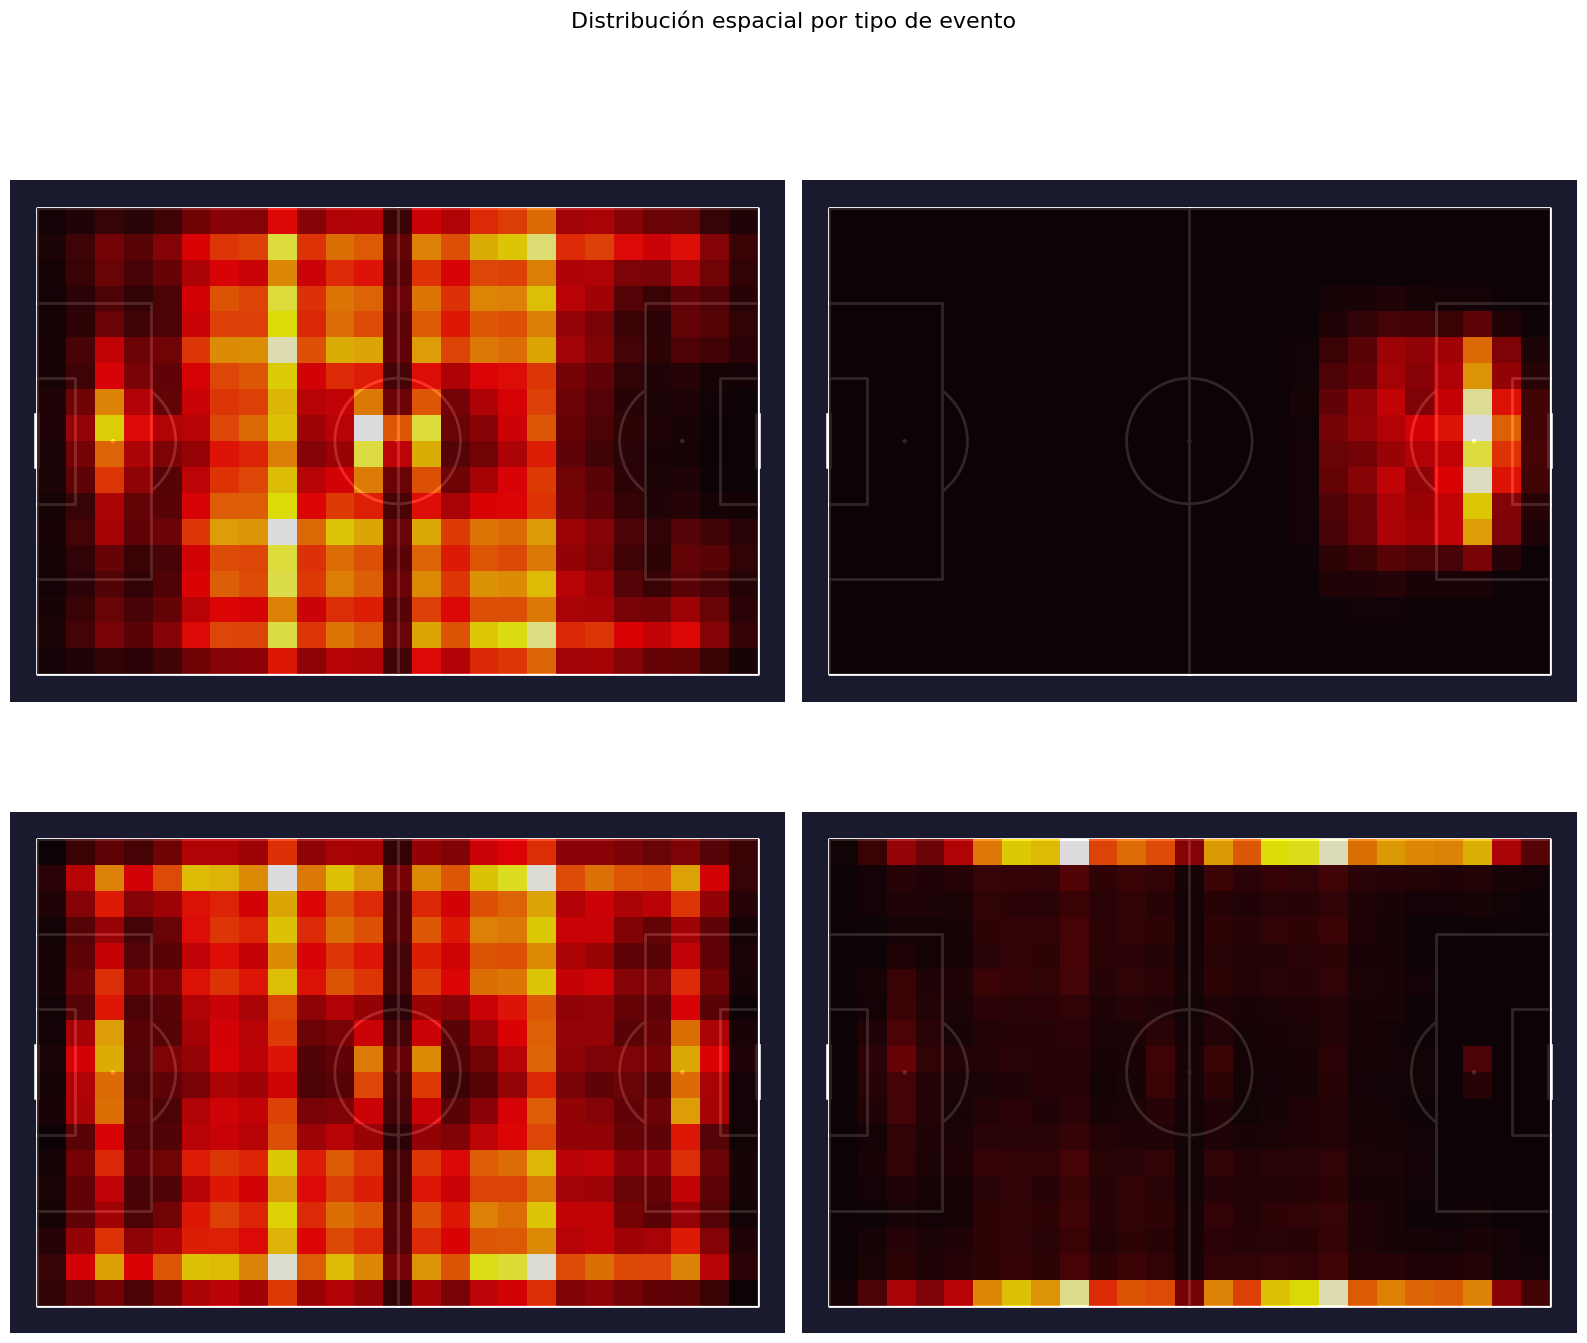

In [23]:
event_types = ['Pass', 'Shot', 'Duel', 'Free Kick']
fig, axes = plt.subplots(2, 2, figsize=(16, 14))

for ax, etype in zip(axes.ravel(), event_types):
    pitch = Pitch(pitch_type='custom', pitch_length=105, pitch_width=68,
                  line_color='white', pitch_color='#1a1a2e')
    pitch.draw(ax=ax)

    mask = df_heatmap['event_name'] == etype
    bs = pitch.bin_statistic(
        df_heatmap.loc[mask, 'x_m'],
        df_heatmap.loc[mask, 'y_m'],
        statistic='count', bins=(25, 18)
    )
    pcm = pitch.heatmap(bs, ax=ax, cmap='hot', edgecolors='none', alpha=0.85)
    ax.set_title(f'{etype} (N={mask.sum():,})', fontsize=13, color='white', pad=10)

plt.suptitle('Distribución espacial por tipo de evento', fontsize=16,
             color='black', y=1.02)
plt.tight_layout()
plt.savefig('figures/04_heatmap_by_event_type.png', dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()

La descomposición por tipo de evento confirma que cada acción tiene una **huella espacial
característica**, un concepto central en el análisis espacial del fútbol:

- **Pases** (sup. izq.): Cobertura amplia con mayor densidad en la mitad propia,
  reflejando el predominio de la fase de construcción.

- **Tiros** (sup. dcha.): Concentración casi exclusiva en el área rival y sus
  inmediaciones, confirmando que el modelo xG operará sobre un dominio espacial
  compacto y bien delimitado.

- **Duelos** (inf. izq.): Distribución más uniforme que los pases, con focos en
  mediocampo y en los laterales del último tercio. Patrón relevante para diferenciar
  perfiles defensivos en el clustering.

- **Free Kicks** (inf. dcha.): Concentración en las líneas de banda (saques de banda
  registrados en esta categoría) y en la frontal del área rival (faltas directas).
  Se observa también actividad en ambas áreas de penalti correspondiente a penaltis
  y faltas defensivas.

### 4.4 Frecuencia de eventos por zona (grid 12×8)

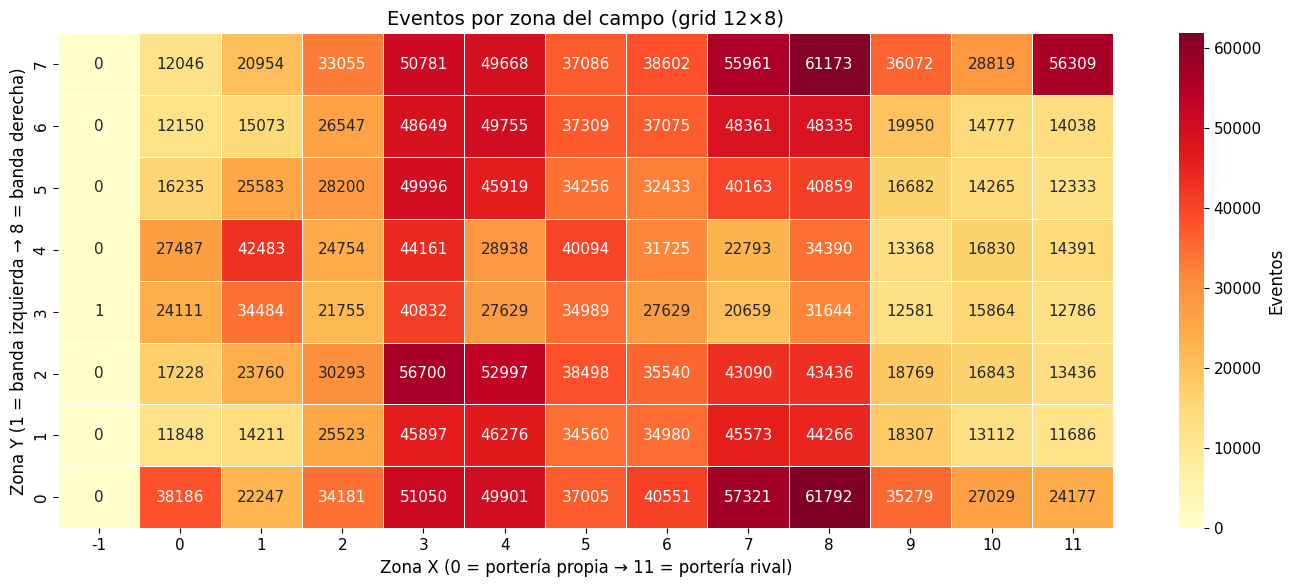

Zona con mayor volumen: zone_x=8, zone_y=0 (61,792 eventos)


In [24]:
zone_counts = (
    df_spatial
    .groupby(['zone_x', 'zone_y'])
    .size()
    .reset_index(name='n_events')
)

zone_matrix = zone_counts.pivot(index='zone_y', columns='zone_x', values='n_events').fillna(0)

fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(zone_matrix, annot=True, fmt='.0f', cmap='YlOrRd',
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Eventos'})
ax.set_xlabel('Zona X (0 = portería propia → 11 = portería rival)')
ax.set_ylabel('Zona Y (1 = banda izquierda → 8 = banda derecha)')
ax.set_title('Eventos por zona del campo (grid 12×8)', fontsize=14)
ax.invert_yaxis()

plt.tight_layout()
plt.savefig('figures/04_zone_grid_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

top_zone = zone_counts.loc[zone_counts['n_events'].idxmax()]
print(f"Zona con mayor volumen: zone_x={int(top_zone['zone_x'])}, "
      f"zone_y={int(top_zone['zone_y'])} ({int(top_zone['n_events']):,} eventos)")

La zona de mayor volumen (zone_x=8, zone_y=0, ~61.800 eventos) corresponde a una
franja lateral ofensiva en la banda. Las zonas con zone_x entre 3 y 8 concentran el
grueso de la actividad, mientras que las zonas próximas a ambas porterías (x ≤ 1 y
x ≥ 10) registran volúmenes notablemente inferiores — acciones escasas pero de alta
trascendencia, que se analizan en detalle en la sección 5.

Se confirma la sobredensificación en las filas y=0 e y=7 (líneas de banda), coherente
con el diagnóstico de artefactos de la celda 4.3. Este grid de 96 zonas es la base del
modelo Expected Threat (xT) de Karun Singh (2018), donde cada celda recibe un valor de
amenaza proporcional a la probabilidad de que una posesión en esa zona culmine en gol.

### 4.5 Precisión de pase por zona

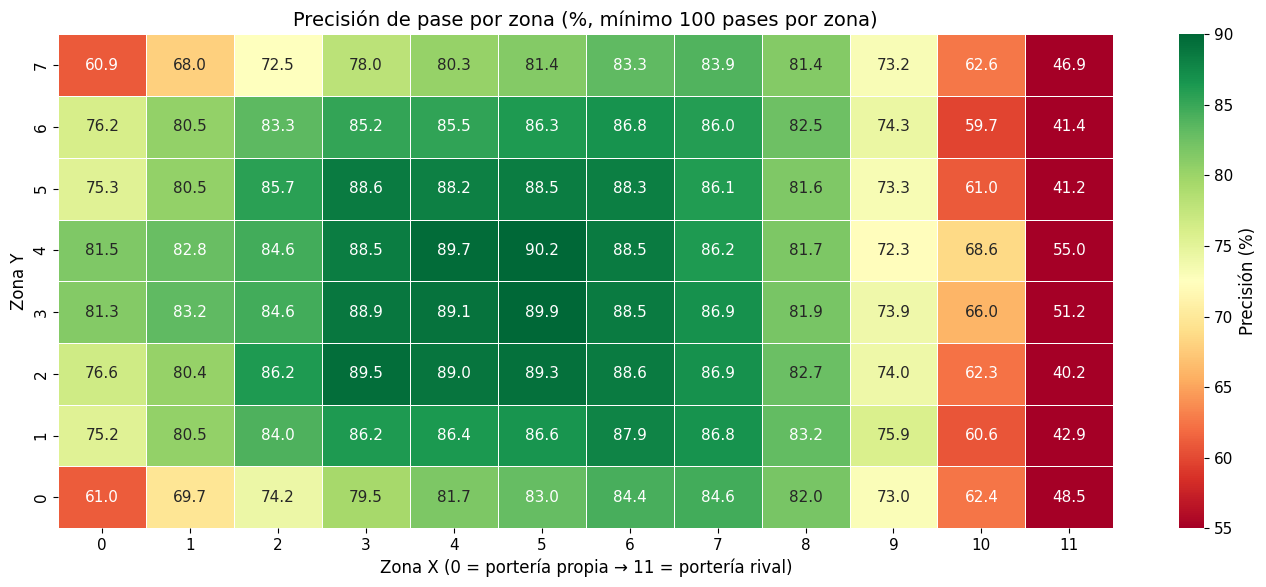

Precisión media en zonas 1-4 (campo propio): 79.8%
Precisión media en zonas 10-12 (último tercio): 60.8%
Diferencia: 18.9 puntos porcentuales


In [25]:
passes_spatial = df_spatial[df_spatial['event_name'] == 'Pass'].copy()

pass_acc_zone = (
    passes_spatial
    .groupby(['zone_x', 'zone_y'])
    .agg(total=('is_accurate', 'count'), accurate=('is_accurate', 'sum'))
    .reset_index()
)
pass_acc_zone['accuracy_pct'] = (pass_acc_zone['accurate'] / pass_acc_zone['total'] * 100)

# Filtrar zonas con muestra suficiente
pass_acc_zone = pass_acc_zone[pass_acc_zone['total'] >= 100]

acc_matrix = pass_acc_zone.pivot(index='zone_y', columns='zone_x', values='accuracy_pct')

fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(acc_matrix, annot=True, fmt='.1f', cmap='RdYlGn',
            linewidths=0.5, ax=ax, vmin=55, vmax=90,
            cbar_kws={'label': 'Precisión (%)'})
ax.set_xlabel('Zona X (0 = portería propia → 11 = portería rival)')
ax.set_ylabel('Zona Y')
ax.set_title('Precisión de pase por zona (%, mínimo 100 pases por zona)', fontsize=14)
ax.invert_yaxis()

plt.tight_layout()
plt.savefig('figures/04_pass_accuracy_by_zone.png', dpi=150, bbox_inches='tight')
plt.show()

# Estadísticas clave
low_acc_zones = pass_acc_zone[pass_acc_zone['zone_x'] >= 9]['accuracy_pct']
high_acc_zones = pass_acc_zone[pass_acc_zone['zone_x'] <= 3]['accuracy_pct']
print(f"Precisión media en zonas 1-4 (campo propio): {high_acc_zones.mean():.1f}%")
print(f"Precisión media en zonas 10-12 (último tercio): {low_acc_zones.mean():.1f}%")
print(f"Diferencia: {high_acc_zones.mean() - low_acc_zones.mean():.1f} puntos porcentuales")

El gradiente de precisión de pase es el hallazgo más relevante de esta sección para
el feature engineering. La diferencia de **18.9 puntos porcentuales** entre el campo
propio (79.8%) y el último tercio rival (60.8%) cuantifica el coste de la progresión.

Se observa además un patrón transversal: las bandas extremas (y=0 e y=7) presentan
la menor precisión en todas las franjas longitudinales. En el último tercio, la
precisión en bandas cae hasta ~40-48%, frente al ~55% en zonas centrales. Esto es
coherente con la naturaleza de los centros laterales: pases de alto riesgo dirigidos
a zonas congestionadas.

Dos implicaciones directas:
1. Valida `pass_goal_distance_delta_m` como feature diferenciadora en el clustering:
   los jugadores que buscan pases verticales hacia el área asumen un coste de precisión
   medible.
2. La precisión de pase bruta es una métrica engañosa sin contexto espacial: un
   centrocampista organizador en zona 4 y un extremo en zona 10 operan en entornos
   de dificultad radicalmente distintos.

### 4.6 Distribución de tiros por liga (shot maps comparados)

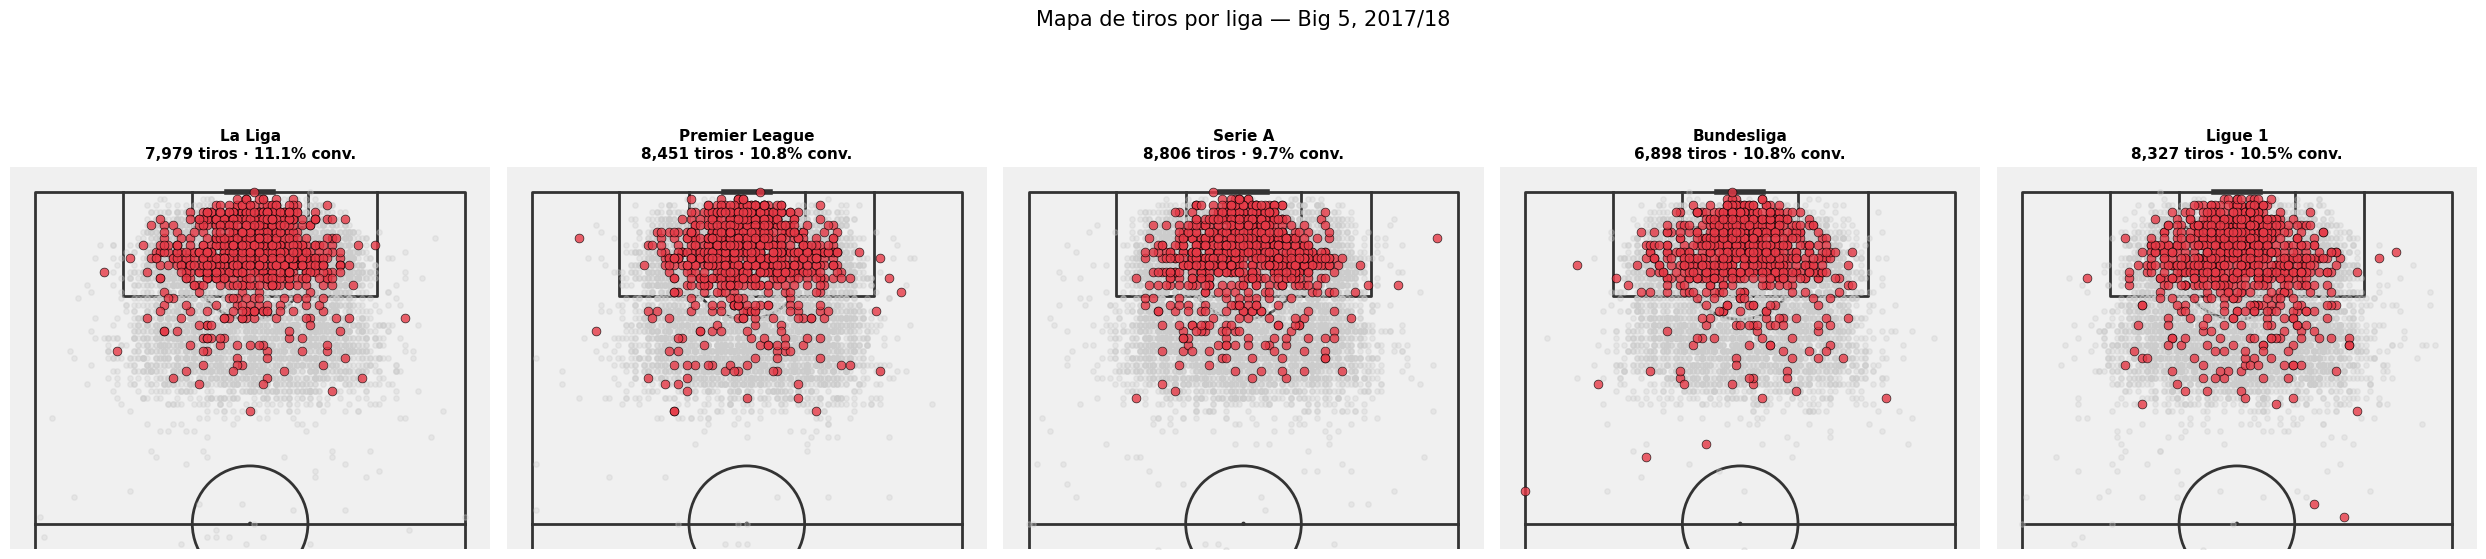

Estadísticas de tiro por liga:

                n_shots  mean_dist  conversion_pct
league                                            
La Liga            7979      18.19           11.08
Bundesliga         6898      18.23           10.83
Premier League     8451      18.28           10.82
Ligue 1            8327      18.95           10.48
Serie A            8806      18.94            9.69


In [26]:
shots_spatial = df_spatial[df_spatial['event_name'] == 'Shot'].copy()

fig, axes = plt.subplots(1, 5, figsize=(25, 6))
league_list = ['La Liga', 'Premier League', 'Serie A', 'Bundesliga', 'Ligue 1']

SHORT_TO_FULL = {v: k for k, v in LEAGUE_SHORT.items()}

for ax, league in zip(axes, league_list):
    pitch = VerticalPitch(pitch_type='custom', pitch_length=105, pitch_width=68,
                          half=True, pitch_color='#f0f0f0', line_color='#333333')
    pitch.draw(ax=ax)
    
    league_shots = shots_spatial[shots_spatial['league'] == league]
    goals = league_shots[league_shots['is_goal'] == True]
    no_goals = league_shots[league_shots['is_goal'] == False]
    
    # No-gol en gris, goles en rojo
    pitch.scatter(no_goals['x_m'], no_goals['y_m'], ax=ax,
                  s=15, color='#cccccc', alpha=0.3, zorder=2)
    pitch.scatter(goals['x_m'], goals['y_m'], ax=ax,
                  s=40, color='#E63946', edgecolors='black', linewidth=0.5,
                  alpha=0.8, zorder=3)
    
    n_shots = len(league_shots)
    n_goals = len(goals)
    conv = n_goals / n_shots * 100 if n_shots > 0 else 0
    
    ax.set_title(f'{league}\n{n_shots:,} tiros · {conv:.1f}% conv.',
                 fontsize=11, fontweight='bold')

plt.suptitle('Mapa de tiros por liga — Big 5, 2017/18', fontsize=15, y=1.05)
plt.tight_layout()
plt.savefig('figures/04_shot_maps_by_league.png', dpi=150, bbox_inches='tight')
plt.show()

# Centro de gravedad de tiros (dato para la conclusión)
shot_gravity = (
    shots_spatial
    .groupby('league')
    .agg(mean_x=('x_m', 'mean'), mean_dist=('dist_to_goal_m', 'mean'),
         n_shots=('wy_event_id', 'count'),
         conversion=('is_goal', 'mean'))
    .sort_values('conversion', ascending=False)
)
shot_gravity['conversion_pct'] = (shot_gravity['conversion'] * 100).round(2)
print("Estadísticas de tiro por liga:\n")
print(shot_gravity[['n_shots', 'mean_dist', 'conversion_pct']].round(2).to_string())

Los shot maps muestran un patrón espacial compartido por las cinco ligas: la inmensa
mayoría de los tiros se origina dentro o en las inmediaciones del área de penalti, con
una distancia media al gol notablemente homogénea (18.19–18.95 m). Las diferencias
entre ligas son de segundo orden:

- **La Liga** presenta la mayor tasa de conversión (11.08%) con el menor número de tiros
  (7.979), solo por delante de la Bundesliga, y la distancia media más corta (18.19 m), sugiriendo un estilo más selectivo
  en la finalización.
- **Serie A** registra el mayor volumen de tiros (8.806) pero la menor conversión (9.69%),
  lo que podría indicar mayor frecuencia de tiros desde posiciones menos favorables.
- **Premier League, Bundesliga y Ligue 1** ocupan posiciones intermedias con conversiones
  del 10.5–10.8%.

Estas diferencias, aunque modestas, confirman que un modelo xG entrenado sobre las cinco
ligas de forma conjunta es viable: el dominio espacial de los tiros es suficientemente
homogéneo. El análisis detallado de la relación distancia–ángulo–gol se desarrolla en
la sección 5.

### Conclusión del análisis espacial

El análisis de la distribución espacial de más de 3 millones de eventos revela
patrones estructurales consistentes con la literatura y con los supuestos del proyecto:

**1. Artefactos de coordenadas identificados y tratados.**
Se documentan dos fenómenos del proceso de etiquetado de Wyscout: acumulación en
esquinas (~2.3% de eventos) y sobredensificación en líneas de banda (~7.6%). Estos
artefactos se excluyen de las visualizaciones de densidad y se preservan en Silver
para el modelado, donde se utilizan variables derivadas (distancia, ángulo) en lugar
de coordenadas crudas.

**2. Cada tipo de evento tiene una huella espacial diferenciada.**
Los pases cubren todo el campo con predominio en la mitad propia; los tiros se
concentran en menos del 20% de la superficie; los duelos se distribuyen en mediocampo
y último tercio. Esta especialización confirma que las coordenadas espaciales codifican
información táctica relevante.

**3. El gradiente de dificultad espacial cuantifica el coste de la progresión.**
La precisión de pase cae 18.9 pp entre el campo propio (79.8%) y el último tercio
rival (60.8%), con caída más pronunciada en bandas (~40-48%). Este resultado valida
`pass_goal_distance_delta_m` como feature diferenciadora para el clustering de estilos.

**4. La distribución de tiros es homogénea entre ligas.**
Las cinco ligas comparten un dominio espacial de tiro similar (distancia media
18.2–19.0 m, conversión 9.7–11.1%), lo que justifica entrenar el modelo xG sobre
el conjunto de las Big 5 sin segmentar por liga.



### Implicaciones para las fases posteriores

- **Modelo xG (sección 5):** `dist_to_goal_m` y `angle_to_goal_deg` están validados
  como features principales. El dominio compacto de los tiros favorece la capacidad
  discriminante del clasificador.

- **Clustering de estilos:** Features espaciales como *% de acciones en el último
  tercio*, *precisión de pase en zonas 9-11* y *pass_goal_distance_delta_m medio*
  capturarán diferencias de estilo entre jugadores verticales y posicionales.

- **Clustering por posición:** La huella espacial diferenciada por tipo de evento
  refuerza la decisión de segmentar por grupo posicional para evitar que el
  clustering agrupe trivialmente por posición en lugar de por estilo.

## 5. Análisis de tiros — preludio del modelo xG

El modelo de Expected Goals (xG) estima la probabilidad de que un tiro termine en gol
a partir de las características del tiro en el momento inmediatamente anterior a su
ejecución. Las features más relevantes documentadas
en la literatura son la distancia al centro de la portería, el ángulo visible entre
postes, la parte del cuerpo utilizada y el contexto de la jugada.

Esta sección explora la relación empírica entre estas variables y la probabilidad de gol
en el dataset Wyscout, con dos objetivos:

1. **Validar visualmente** que las features precalculadas en Silver (`dist_to_goal_m`,
   `angle_to_goal_deg`, `body_part`) son predictores viables.
2. **Definir el dataset de entrenamiento** del modelo xG: qué tiros se incluyen,
   cuáles se excluyen y por qué.

### 5.1 Dataset de tiros para el modelo xG

Seleccionan los tiros mediante el filtro `event_name = 'Shot'`, lo que excluye
automáticamente los penaltis y las faltas directas, registrados en Wyscout bajo
`event_name = 'Free Kick'`. La exclusión de penaltis es práctica estándar en la
literatura de xG (Soccermatics, 2016; Dato Fútbol, 2020; Damavis, 2025): su
probabilidad de gol (~76%) responde a condiciones únicas (distancia fija, sin
barrera, 1v1 con portero) que no son generalizables al resto de situaciones de tiro.

Se mantienen los tiros bloqueados, ya que el modelo xG evalúa la probabilidad de gol
en el momento inmediatamente anterior a la ejecución del disparo — la información
sobre si el tiro fue bloqueado o no es posterior al evento y por tanto no debe
condicionar la estimación.

In [27]:
shots_xg = df[
    (df['event_name'] == 'Shot') &
    (df['dist_to_goal_m'].notna()) &
    (df['angle_to_goal_deg'].notna())
].copy()

# Para referencia: penaltis y faltas directas (excluidos)
penalties = df[(df['is_penalty_shot'] == True)]
free_kick_shots = df[(df['is_free_kick_shot'] == True)]

print("Dataset de tiros para modelo xG")
print("=" * 60)
print(f"Tiros (event_name='Shot'):        {len(shots_xg):,}")
print(f"  → Goles:                        {shots_xg['is_goal'].sum():,.0f} "
      f"({shots_xg['is_goal'].mean()*100:.1f}%)")
print(f"\nExcluidos:")
print(f"  Penaltis:                       {len(penalties):,} "
      f"(conv. {penalties['is_goal'].mean()*100:.1f}%)")
print(f"  Tiros de falta directa:         {len(free_kick_shots):,} "
      f"(conv. {free_kick_shots['is_goal'].mean()*100:.1f}%)")

print(f"\nFeatures disponibles:")
print(f"  dist_to_goal_m:  {shots_xg['dist_to_goal_m'].min():.1f} – "
      f"{shots_xg['dist_to_goal_m'].max():.1f} m  (media: {shots_xg['dist_to_goal_m'].mean():.1f})")
print(f"  angle_to_goal_deg: {shots_xg['angle_to_goal_deg'].min():.1f} – "
      f"{shots_xg['angle_to_goal_deg'].max():.1f}°  (media: {shots_xg['angle_to_goal_deg'].mean():.1f})")
print(f"  body_part:       {shots_xg['body_part'].value_counts().to_dict()}")

# Clase balanceada?
print(f"\nBalance de clases: {shots_xg['is_goal'].sum():.0f} goles vs "
      f"{(~shots_xg['is_goal']).sum():,.0f} no-goles (ratio 1:{(~shots_xg['is_goal']).sum()/shots_xg['is_goal'].sum():.1f})")

Dataset de tiros para modelo xG
Tiros (event_name='Shot'):        40,461
  → Goles:                        4,271 (10.6%)

Excluidos:
  Penaltis:                       541 (conv. 72.6%)
  Tiros de falta directa:         2,038 (conv. 6.2%)

Features disponibles:
  dist_to_goal_m:  0.7 – 104.0 m  (media: 18.5)
  angle_to_goal_deg: 0.0 – 180.0°  (media: 23.8)
  body_part:       {'right': 20619, 'left': 13323, 'head_body': 6519}

Balance de clases: 4271 goles vs 36,190 no-goles (ratio 1:8.5)


El dataset de entrenamiento contiene **40.461 tiros con 4.271 goles** (tasa base del
10.6%), un desbalance de clases 1:8.5 que es consistente con la literatura — Dato Fútbol
(2020) reporta ~14% sobre el mismo dataset pero excluyendo tiros bloqueados; Damavis
(2025) reporta ~11% sobre datos Wyscout comerciales. Este desbalance deberá tenerse en
cuenta en la fase de modelado mediante técnicas como ponderación de clases o umbrales
de decisión ajustados.

### 5.2 Probabilidad de gol en función de la distancia 
Función que mide la relación distancia vs gol. La distancia al centro de la portería es considerada la feature más relevante en cualquiero modelo xG.
Esta es la curva fundamental que el modelo xG debe capturar.

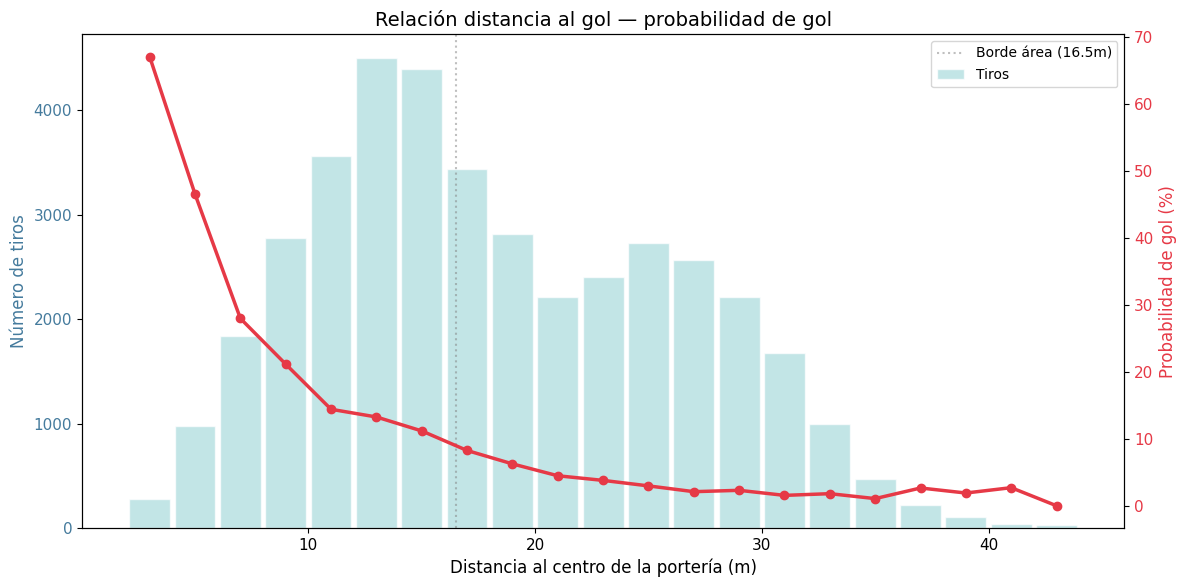

Dentro del área (≤16.5m): 19,124 tiros, 18.0% conversión
Fuera del área (>16.5m):  21,337 tiros, 3.9% conversión


In [28]:
# Bins de 2 metros para estabilidad estadística
shots_xg['dist_bin'] = pd.cut(shots_xg['dist_to_goal_m'], bins=range(0, 52, 2))

dist_curve = (
    shots_xg.groupby('dist_bin', observed=False)
    .agg(shots=('is_goal', 'count'), goals=('is_goal', 'sum'))
    .reset_index()
)
dist_curve['goal_pct'] = (dist_curve['goals'] / dist_curve['shots'] * 100)
dist_curve['dist_mid'] = dist_curve['dist_bin'].apply(lambda x: x.mid if pd.notna(x) else None)
dist_curve = dist_curve[dist_curve['shots'] >= 30]  # estabilidad

fig, ax1 = plt.subplots(figsize=(12, 6))

# Barras: volumen de tiros
ax1.bar(dist_curve['dist_mid'], dist_curve['shots'], width=1.8,
        color='#A8DADC', edgecolor='white', alpha=0.7, label='Tiros')
ax1.set_xlabel('Distancia al centro de la portería (m)')
ax1.set_ylabel('Número de tiros', color='#457B9D')
ax1.tick_params(axis='y', labelcolor='#457B9D')

# Línea: probabilidad de gol
ax2 = ax1.twinx()
ax2.plot(dist_curve['dist_mid'], dist_curve['goal_pct'],
         color='#E63946', marker='o', linewidth=2.5, label='P(gol)')
ax2.set_ylabel('Probabilidad de gol (%)', color='#E63946')
ax2.tick_params(axis='y', labelcolor='#E63946')

ax1.set_title('Relación distancia al gol — probabilidad de gol', fontsize=14)
ax1.axvline(x=16.5, color='gray', linestyle=':', alpha=0.5, label='Borde área (16.5m)')
ax1.legend(loc='upper right')

plt.tight_layout()
plt.savefig('figures/05_distance_goal_probability.png', dpi=150, bbox_inches='tight')
plt.show()

# Estadísticas clave
inside_box = shots_xg[shots_xg['dist_to_goal_m'] <= 16.5]
outside_box = shots_xg[shots_xg['dist_to_goal_m'] > 16.5]
print(f"Dentro del área (≤16.5m): {len(inside_box):,} tiros, "
      f"{inside_box['is_goal'].mean()*100:.1f}% conversión")
print(f"Fuera del área (>16.5m):  {len(outside_box):,} tiros, "
      f"{outside_box['is_goal'].mean()*100:.1f}% conversión")


La relación distancia – probabilidad de gol, sigue un decaimiento exponencial: desde ~65% a
menos de 3 metros hasta estabilizarse por debajo del 5% a partir de los 20 metros.
El umbral del área de penalti (16.5m) marca una frontera nítida: los tiros dentro
del área convierten al 18.0% frente al 3.9% de los tiros exteriores, una diferencia
de 4.6x.

El pico de volumen de tiros se sitúa entre 12 y 16 metros (borde del área y frontal),
no en las zonas de máxima conversión (0-6m), lo que indica que la mayoría de los tiros
se ejecutan desde posiciones subóptimas — precisamente la información que el modelo
xG debe capturar.

### 5.3 Probabilidad de gol en función del ángulo visible

El ángulo visible entre postes mide cuánta portería "ve" el tirador. A mayor ángulo
(posición más central y cercana), más opciones tiene de anotar el gol. 

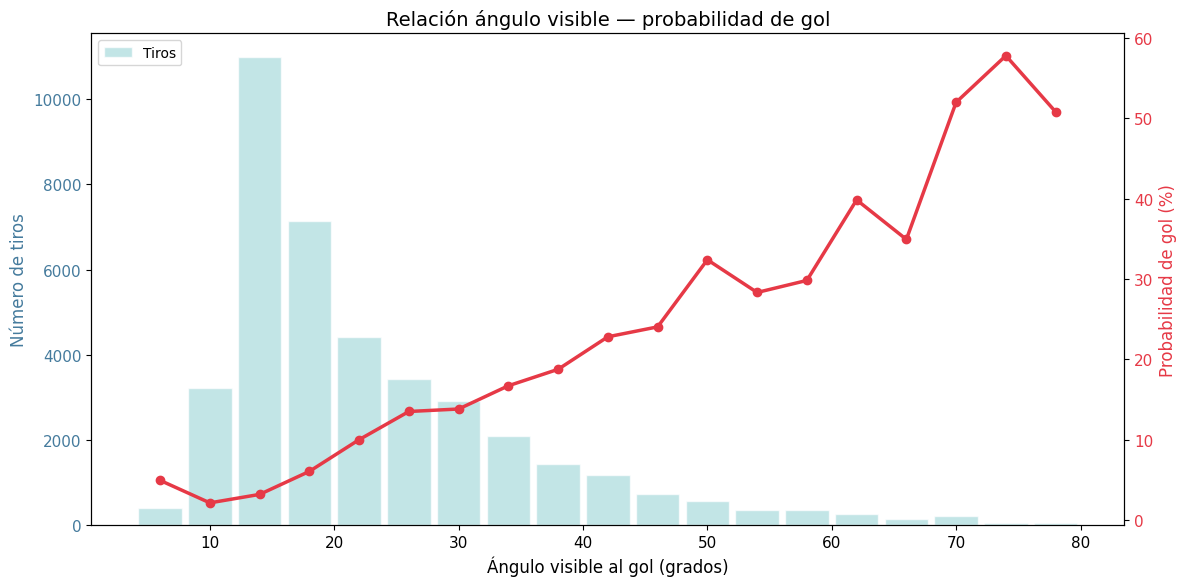

In [29]:
shots_xg['angle_bin'] = pd.cut(shots_xg['angle_to_goal_deg'],
                                bins=range(0, 82, 4))

angle_curve = (
    shots_xg.groupby('angle_bin', observed=False)
    .agg(shots=('is_goal', 'count'), goals=('is_goal', 'sum'))
    .reset_index()
)
angle_curve['goal_pct'] = (angle_curve['goals'] / angle_curve['shots'] * 100)
angle_curve['angle_mid'] = angle_curve['angle_bin'].apply(lambda x: x.mid if pd.notna(x) else None)
angle_curve = angle_curve[angle_curve['shots'] >= 30]

fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.bar(angle_curve['angle_mid'], angle_curve['shots'], width=3.5,
        color='#A8DADC', edgecolor='white', alpha=0.7, label='Tiros')
ax1.set_xlabel('Ángulo visible al gol (grados)')
ax1.set_ylabel('Número de tiros', color='#457B9D')
ax1.tick_params(axis='y', labelcolor='#457B9D')

ax2 = ax1.twinx()
ax2.plot(angle_curve['angle_mid'], angle_curve['goal_pct'],
         color='#E63946', marker='o', linewidth=2.5, label='P(gol)')
ax2.set_ylabel('Probabilidad de gol (%)', color='#E63946')
ax2.tick_params(axis='y', labelcolor='#E63946')

ax1.set_title('Relación ángulo visible — probabilidad de gol', fontsize=14)
ax1.legend(loc='upper left')

plt.tight_layout()
plt.savefig('figures/05_angle_goal_probability.png', dpi=150, bbox_inches='tight')
plt.show()

La relación ángulo–probabilidad de gol es monótonamente creciente: desde ~5% para ángulos
menores de 10° (tiros desde posiciones muy laterales) hasta ~50-55% para ángulos
superiores a 65° (tiros muy centrales y cercanos). El grueso de los tiros se concentra
en ángulos de 10-20° (~18.000 tiros), correspondientes al borde del área en posiciones
laterales.

Distancia y ángulo están correlacionados (un tiro cercano tiende a tener mayor ángulo),
pero no son redundantes: dos tiros a la misma distancia pero con distinto ángulo tienen
probabilidades de gol muy diferentes. Esto justifica incluir ambas features en el modelo.

### 5.4 Conversión por parte del cuerpo y contexto
La parte del cuerpo y el contexto de la jugada son features categóricas que complementan
las variables espaciales. La primera está disponible directamente en los tags de Wyscout;
la segunda se deriva de los tags `is_counterattack` e `is_opportunity`.

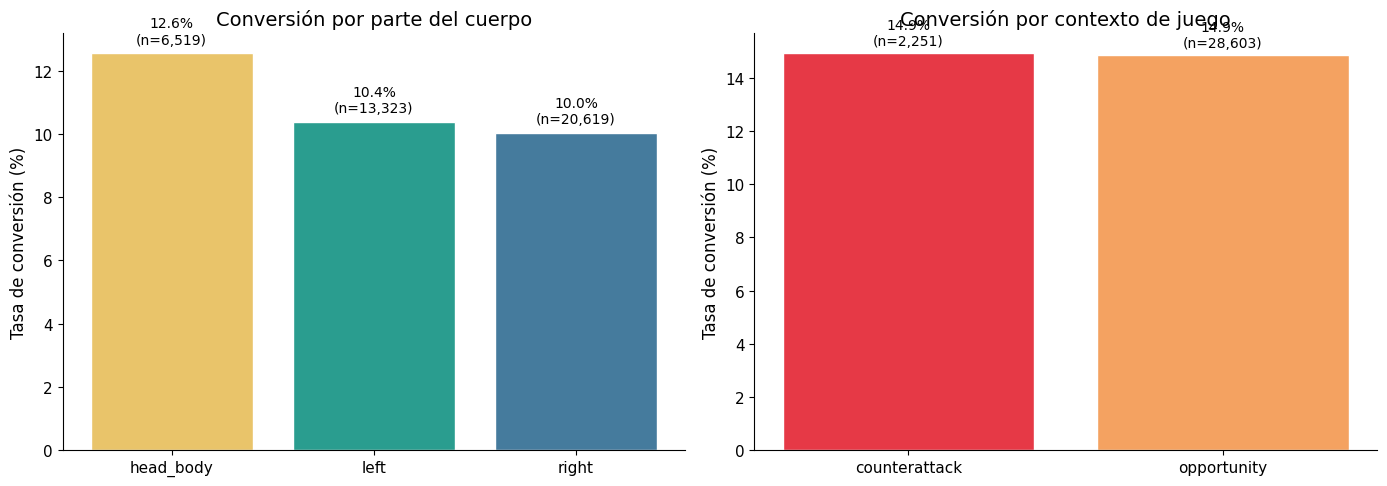

Conversión por parte del cuerpo:
body_part  shots  goals  conv_pct  avg_dist  avg_angle
head_body   6519    818     12.55 10.514045  37.813379
     left  13323   1383     10.38 19.865884  21.093781
    right  20619   2070     10.04 20.209840  21.106411

Conversión por contexto:
      context  shots  goals  conv_pct  avg_dist
counterattack   2251    336     14.93      18.6
  opportunity  28603   4250     14.86      16.6


In [30]:
# Body part
bp_stats = (
    shots_xg[shots_xg['body_part'].notna()]
    .groupby('body_part')
    .agg(shots=('is_goal', 'count'), goals=('is_goal', 'sum'),
         avg_dist=('dist_to_goal_m', 'mean'), avg_angle=('angle_to_goal_deg', 'mean'))
    .reset_index()
)
bp_stats['conv_pct'] = (bp_stats['goals'] / bp_stats['shots'] * 100).round(2)
bp_stats = bp_stats.sort_values('conv_pct', ascending=False)

# Contexto: contraataque, oportunidad (big chance proxy)
context_vars = ['is_counterattack', 'is_opportunity']
context_rows = []
for var in context_vars:
    sub = shots_xg[shots_xg[var] == True]
    context_rows.append({
        'context': var.replace('is_', ''),
        'shots': len(sub),
        'goals': sub['is_goal'].sum(),
        'conv_pct': round(sub['is_goal'].mean() * 100, 2) if len(sub) > 0 else 0,
        'avg_dist': round(sub['dist_to_goal_m'].mean(), 1) if len(sub) > 0 else 0
    })
context_stats = pd.DataFrame(context_rows)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Body part
colors_bp = {'head_body': '#E9C46A', 'right': '#457B9D', 'left': '#2A9D8F'}
bars = axes[0].bar(bp_stats['body_part'], bp_stats['conv_pct'],
                    color=[colors_bp.get(bp, '#999') for bp in bp_stats['body_part']],
                    edgecolor='white')
for bar, pct, n in zip(bars, bp_stats['conv_pct'], bp_stats['shots']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{pct:.1f}%\n(n={n:,})', ha='center', fontsize=10)
axes[0].set_ylabel('Tasa de conversión (%)')
axes[0].set_title('Conversión por parte del cuerpo')
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# Contexto
bars2 = axes[1].bar(context_stats['context'], context_stats['conv_pct'],
                     color=['#E63946', '#F4A261', '#264653'], edgecolor='white')
for bar, pct, n in zip(bars2, context_stats['conv_pct'], context_stats['shots']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{pct:.1f}%\n(n={n:,})', ha='center', fontsize=10)
axes[1].set_ylabel('Tasa de conversión (%)')
axes[1].set_title('Conversión por contexto de juego')
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('figures/05_conversion_bodypart_context.png', dpi=150, bbox_inches='tight')
plt.show()

print("Conversión por parte del cuerpo:")
print(bp_stats[['body_part', 'shots', 'goals', 'conv_pct', 'avg_dist', 'avg_angle']].to_string(index=False))
print("\nConversión por contexto:")
print(context_stats.to_string(index=False))


Los tiros de cabeza convierten más (12.6%) que los de pie derecho (10.0%) o izquierdo
(10.4%), pero esto se explica por la distancia media: los cabezazos se ejecutan a 10.5m
(dentro del área, tras centros laterales) frente a los ~20m de los tiros con el pie.
La parte del cuerpo no aporta información independiente de la posición — es un proxy
de la situación de juego. No obstante, se incluirá como feature categórica en el modelo
porque puede capturar la dificultad diferencial de rematar de cabeza vs pie.

Los tiros en contraataque y los marcados como *opportunity* presentan conversiones
similares (~14.9%), significativamente superiores a la tasa base (10.6%). El tag
`is_opportunity` de Wyscout señala situaciones de ventaja para el atacante y cubre
el 70% de los tiros, lo que sugiere un umbral de etiquetado amplio por parte de los
operadores. Su utilidad como feature se evaluará en el modelo.

### 5.5 Tasa de conversión por zona (grid 12×8)

El heatmap de conversión sintetiza distancia y ángulo en un único mapa 2D, mostrando
la "superficie de probabilidad" que el modelo xG debe aprender.

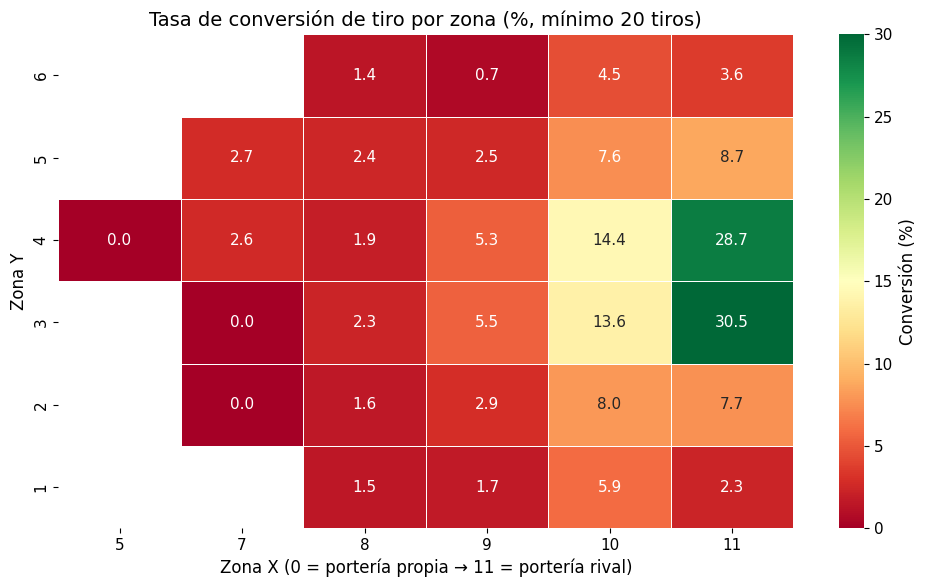

Zonas con ≥20 tiros: 29

Top 3 zonas por conversión:
 zone_x  zone_y  shots  goals  conv_pct
     11       3   2832    864      30.5
     11       4   3026    867      28.7
     10       4   4760    685      14.4


In [31]:
# Solo zonas ofensivas (zone_x >= 6) con muestra suficiente
shot_zones = (
    shots_xg
    .groupby(['zone_x', 'zone_y'])
    .agg(shots=('is_goal', 'count'), goals=('is_goal', 'sum'))
    .reset_index()
)
shot_zones['conv_pct'] = (shot_zones['goals'] / shot_zones['shots'] * 100).round(1)
shot_zones_filtered = shot_zones[shot_zones['shots'] >= 20]

conv_matrix = shot_zones_filtered.pivot(index='zone_y', columns='zone_x', values='conv_pct')

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(conv_matrix, annot=True, fmt='.1f', cmap='RdYlGn',
            linewidths=0.5, ax=ax, vmin=0, vmax=30,
            cbar_kws={'label': 'Conversión (%)'})
ax.set_xlabel('Zona X (0 = portería propia → 11 = portería rival)')
ax.set_ylabel('Zona Y')
ax.set_title('Tasa de conversión de tiro por zona (%, mínimo 20 tiros)', fontsize=14)
ax.invert_yaxis()

plt.tight_layout()
plt.savefig('figures/05_shot_conversion_by_zone.png', dpi=150, bbox_inches='tight')
plt.show()

# Resumen
print(f"Zonas con ≥20 tiros: {len(shot_zones_filtered)}")
top = shot_zones_filtered.nlargest(3, 'conv_pct')
print(f"\nTop 3 zonas por conversión:")
print(top[['zone_x', 'zone_y', 'shots', 'goals', 'conv_pct']].to_string(index=False))


Las zonas centrales próximas a la portería (zone_x=11, zone_y=3-4) alcanzan tasas de
conversión del 28-30%, mientras que las zonas laterales a la misma distancia longitudinal
(zone_y=1-2, 5-6) caen al 2-9%. Este gradiente central-lateral confirma que el ángulo
aporta información discriminante más allá de la distancia. Las zonas más retrasadas
(zone_x ≤ 8) presentan conversiones inferiores al 3%, consistente con la curva de
distancia de la celda 5.2.

### Conclusión del análisis de tiros

El análisis exploratorio de los 40.461 tiros del dataset valida las features que
alimentarán el modelo xG propio:

**1. Distancia como predictor principal.** La probabilidad de gol decae exponencialmente
con la distancia: 18.0% dentro del área vs 3.9% fuera (ratio 4.6x). Esta variable
presenta la relación univariante más fuerte con el outcome y será la feature dominante
del modelo.

**2. Ángulo como complemento espacial.** El ángulo visible aporta información independiente
de la distancia: a igual distancia, los tiros centrales convierten 3-4 veces más que los
laterales. La combinación distancia + ángulo define la "superficie de probabilidad"
bidimensional que el modelo debe capturar.

**3. Body part como proxy de situación.** Los cabezazos convierten más por ejecutarse
a menor distancia, no por una ventaja intrínseca de la técnica. Se incluirá como feature
categórica para capturar el efecto residual tras controlar por posición.

**4. Variables de contexto con cautela.** `is_counterattack` e `is_opportunity` muestran
conversiones superiores a la base (~14.9% vs 10.6%), pero la alta cobertura de
`is_opportunity` (70% de los tiros) limita su poder discriminante. Se evaluarán en
el modelo pero sin expectativa de alta importancia.

### Dataset de entrenamiento definido

| Parámetro | Valor |
|---|---|
| Tiros totales | 40.461 |
| Goles | 4.271 (10.6%) |
| Excluidos | Penaltis (541), faltas directas (2.038) |
| Features continuas | `dist_to_goal_m`, `angle_to_goal_deg` |
| Features categóricas | `body_part`, `is_counterattack`, `is_opportunity` |
| Features candidatas adicionales | `is_head_body`, `zone_x`, `zone_y`, `is_first_half` |
| Balance de clases | 1:8.5 (requiere gestión en modelado) |

Este dataset y estas features constituyen el input de la siguiente fase del proyecto:
la construcción del modelo xG propio mediante regresión logística y/o gradient boosting.

## 6. Análisis de pases

Los pases representan el ~51% de los eventos del dataset y son la base del feature
engineering para el clustering de estilos de juego. Esta sección analiza la precisión
por tipo de pase y la distribución de pases progresivos, dos dimensiones que
diferencian estilos directos de posicionales.

### 6.1 Precisión por tipo de pase y pases progresivos

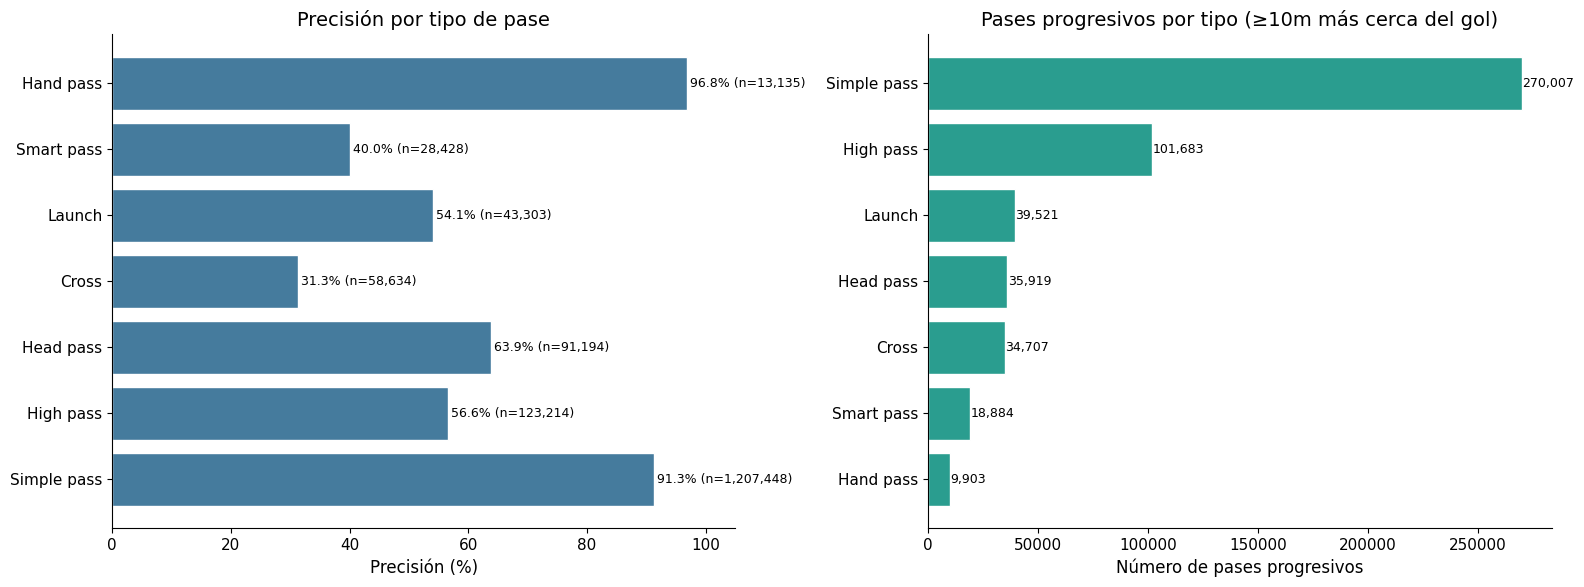

Total pases: 1,565,356
Pases progresivos: 510,624 (32.6%)
Precisión global: 82.8%

Precisión de pases progresivos: 71.4%
Precisión de pases no progresivos: 88.4%

Tabla completa:
sub_event_name   total  accuracy_pct  avg_distance  prog_pct
   Simple pass 1207448          91.3     16.963440      22.4
     High pass  123214          56.6     39.195167      82.5
     Head pass   91194          63.9     15.956991      39.4
         Cross   58634          31.3     37.743126      59.2
        Launch   43303          54.1     41.966341      91.3
    Smart pass   28428          40.0     21.262986      66.4
     Hand pass   13135          96.8     27.072978      75.4


In [32]:
passes = df[df['event_name'] == 'Pass'].copy()

pass_stats = (
    passes.groupby('sub_event_name')
    .agg(
        total=('is_accurate', 'count'),
        accurate=('is_accurate', 'sum'),
        avg_distance=('pass_distance_m', 'mean'),
        progressive=('is_progressive_pass', 'sum')
    )
    .reset_index()
)
pass_stats['accuracy_pct'] = (pass_stats['accurate'] / pass_stats['total'] * 100).round(1)
pass_stats['prog_pct'] = (pass_stats['progressive'] / pass_stats['total'] * 100).round(1)
pass_stats = pass_stats.sort_values('total', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Precisión por tipo
axes[0].barh(pass_stats['sub_event_name'], pass_stats['accuracy_pct'],
             color='#457B9D', edgecolor='white')
for i, (pct, n) in enumerate(zip(pass_stats['accuracy_pct'], pass_stats['total'])):
    axes[0].text(pct + 0.5, i, f'{pct:.1f}% (n={n:,})', va='center', fontsize=9)
axes[0].set_xlabel('Precisión (%)')
axes[0].set_title('Precisión por tipo de pase')
axes[0].set_xlim(0, 105)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# Distribución de pases progresivos por tipo
prog_data = pass_stats[pass_stats['progressive'] > 0].sort_values('progressive', ascending=True)
axes[1].barh(prog_data['sub_event_name'], prog_data['progressive'],
             color='#2A9D8F', edgecolor='white')
for i, val in enumerate(prog_data['progressive']):
    axes[1].text(val + 200, i, f'{val:,}', va='center', fontsize=9)
axes[1].set_xlabel('Número de pases progresivos')
axes[1].set_title('Pases progresivos por tipo (≥10m más cerca del gol)')
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('figures/06_pass_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

# Resumen
total_passes = len(passes)
total_prog = passes['is_progressive_pass'].sum()
print(f"Total pases: {total_passes:,}")
print(f"Pases progresivos: {total_prog:,} ({total_prog/total_passes*100:.1f}%)")
print(f"Precisión global: {passes['is_accurate'].mean()*100:.1f}%")
print(f"\nPrecisión de pases progresivos: "
      f"{passes[passes['is_progressive_pass']]['is_accurate'].mean()*100:.1f}%")
print(f"Precisión de pases no progresivos: "
      f"{passes[~passes['is_progressive_pass']]['is_accurate'].mean()*100:.1f}%")

print("\nTabla completa:")
print(pass_stats[['sub_event_name', 'total', 'accuracy_pct', 'avg_distance', 'prog_pct']]
      .to_string(index=False))


Los **Simple passes** dominan el volumen (1.2M, 77%) con una precisión del 91.3%,
mientras que los tipos de alto valor táctico presentan precisiones significativamente
menores: **Crosses** 31.3%, **Smart passes** 40.0%, **Launches** 54.1%. Esta jerarquía
confirma el gradiente de dificultad documentado en la sección 4.

Los pases progresivos (≥10m más cerca del gol) representan el **32.6%** del total,
con una precisión del **71.4%** frente al 88.4% de los no progresivos, una diferencia
de 17 pp que cuantifica el coste de la verticalidad. Dentro de los progresivos, los
**High passes** destacan con un 82.5% de ratio progresivo (la mayoría de los pases
largos buscan avanzar) y los **Launches** con un 91.3%.

Para el clustering de estilos, las features derivadas de este análisis serán:
*% de smart passes*, *% de pases progresivos*, *% de crosses*, *precisión global*
y *pass_goal_distance_delta_m medio* — métricas que distinguen jugadores verticales
y arriesgados de perfiles posicionales y de circulación.


## 7. Análisis defensivo

Los eventos defensivos (duelos, intercepciones, entradas) son fundamentales para
construir el perfil de estilo de los defensas y mediocampistas con un rol más defensivo en el
clustering. Esta sección cuantifica la distribución y eficacia de estas acciones.


### 7.1 Duelos e intercepciones por posición

Acciones defensivas por posición (por 1000 eventos):
position_code  events  duels_per1000  interceptions_per1000  clearances_per1000  tackles_per1000  fouls_committed_per1000
           FW  484731          412.3                   32.5                 0.0              5.1                     23.6
           MD 1097544          271.7                   52.9                 0.0              8.1                     18.3
           DF 1120284          221.4                   75.5                 0.0              7.9                     14.2
           GK  142798           19.1                   40.9                 0.0              0.6                      1.5


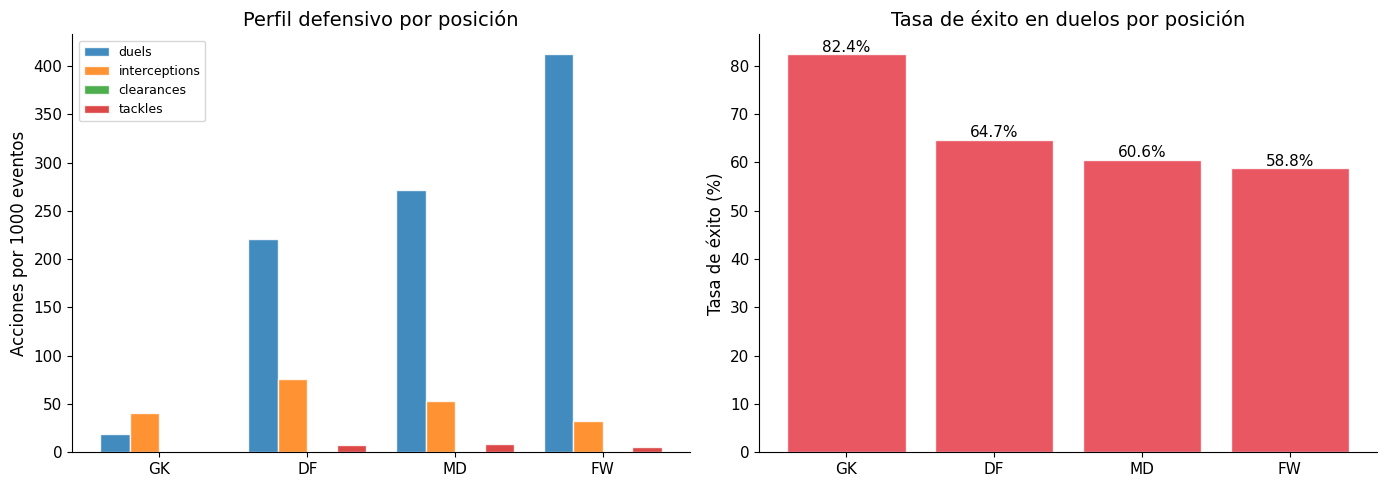

In [33]:
# Merge con posiciones
df_def = df.merge(
    players[['wy_player_id', 'position_code']],
    left_on='player_id', right_on='wy_player_id', how='inner'
)

# Duelos
duels = df_def[df_def['event_name'] == 'Duel']
duel_stats = (
    duels.groupby(['position_code', 'sub_event_name'])
    .agg(total=('is_accurate', 'count'), won=('is_accurate', 'sum'))
    .reset_index()
)
duel_stats['win_pct'] = (duel_stats['won'] / duel_stats['total'] * 100).round(1)

# Resumen por posición
def_summary = (
    df_def.groupby('position_code')
    .agg(
        events=('wy_event_id', 'count'),
        duels=('event_name', lambda x: (x == 'Duel').sum()),
        interceptions=('is_interception', 'sum'),
        clearances=('is_clearance', 'sum'),
        tackles=('is_sliding_tackle', 'sum'),
        fouls_committed=('event_name', lambda x: (x == 'Foul').sum())
    )
    .reset_index()
)

# Normalizar por 1000 eventos para comparabilidad
for col in ['duels', 'interceptions', 'clearances', 'tackles', 'fouls_committed']:
    def_summary[f'{col}_per1000'] = (def_summary[col] / def_summary['events'] * 1000).round(1)

print("Acciones defensivas por posición (por 1000 eventos):")
print("=" * 70)
print(def_summary[['position_code', 'events', 'duels_per1000', 'interceptions_per1000',
                     'clearances_per1000', 'tackles_per1000', 'fouls_committed_per1000']]
      .sort_values('duels_per1000', ascending=False)
      .to_string(index=False))

# Tasa de éxito en duelos por posición
duel_by_pos = (
    duels.groupby('position_code')
    .agg(total=('is_accurate', 'count'), won=('is_accurate', 'sum'))
    .reset_index()
)
duel_by_pos['win_pct'] = (duel_by_pos['won'] / duel_by_pos['total'] * 100).round(1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Acciones defensivas por posición
metrics = ['duels_per1000', 'interceptions_per1000', 'clearances_per1000', 'tackles_per1000']
pos_order = ['GK', 'DF', 'MD', 'FW']
x = np.arange(len(pos_order))
width = 0.2

for i, metric in enumerate(metrics):
    vals = [def_summary[def_summary['position_code'] == p][metric].values[0] for p in pos_order]
    axes[0].bar(x + i * width, vals, width, label=metric.replace('_per1000', ''),
                edgecolor='white', alpha=0.85)

axes[0].set_xticks(x + width * 1.5)
axes[0].set_xticklabels(pos_order)
axes[0].set_ylabel('Acciones por 1000 eventos')
axes[0].set_title('Perfil defensivo por posición')
axes[0].legend(fontsize=9)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# Tasa de éxito en duelos
duel_by_pos_sorted = duel_by_pos.set_index('position_code').loc[pos_order]
axes[1].bar(duel_by_pos_sorted.index, duel_by_pos_sorted['win_pct'],
            color='#E63946', edgecolor='white', alpha=0.85)
for i, (pos, pct) in enumerate(zip(duel_by_pos_sorted.index, duel_by_pos_sorted['win_pct'])):
    axes[1].text(i, pct + 0.5, f'{pct:.1f}%', ha='center', fontsize=11)
axes[1].set_ylabel('Tasa de éxito (%)')
axes[1].set_title('Tasa de éxito en duelos por posición')
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('figures/07_defensive_analysis.png', dpi=150, bbox_inches='tight')
plt.show()


El perfil defensivo varía drásticamente por posición:

- **Delanteros (FW):** Sorprendentemente la mayor tasa de duelos por evento (412/1000),
  lo que se explica porque sus eventos son predominantemente disputas (pressing, duelos
  ofensivos) frente a un menor volumen total de acciones técnicas. Sin embargo, su
  tasa de éxito es la más baja (58.8%).

- **Defensas (DF):** Mayor tasa de intercepciones (75.5/1000) y éxito en duelos del
  64.7%, consistente con su rol de recuperación y contención.

- **Mediocampistas (MD):** Perfil intermedio con intercepciones relevantes (52.9/1000)
  y duelos frecuentes (271.7/1000). Será el grupo posicional donde el clustering
  puede revelar más diversidad de estilos defensivos.

- **Porteros (GK):** Pocos duelos pero con éxito del 82.4% — reflejando que sus
  intervenciones son mayoritariamente exitosas (salidas, 1v1 ganados).

Las features defensivas para el clustering serán: *duelos por 90*, *% de duelos ganados*,
*intercepciones por 90*, *entradas por 90* y *faltas cometidas por 90*.

**Nota:** La variable `is_clearance` registra 0 eventos. Tras validar los 57 tag IDs del 
dataset confirmamos que esta feature **no existe en la versión pública** del dataset. Sin embargo, 
las clearances sí se registran como `sub_event_name = 'Clearance'` dentro del tipo de evento
`Others on the ball`, por lo que pueden recuperarse en la fase de agregación per90
sin necesidad de depender del tag booleano.

Se verificaron los 32 tags mapeados en la capa Silver: todos los IDs son correctos
y consistentes con la documentación oficial. No se detectaron errores de asignación
en ninguna variable derivada.

## 8. Comparación entre ligas

Síntesis de las diferencias entre las Big 5 documentadas en secciones anteriores,
complementada con un perfil multi-métrica por liga.

### 8.1 Perfil táctico por liga

In [34]:
league_profile = (
    df.groupby('league')
    .agg(
        matches=('match_id', 'nunique'),
        events=('wy_event_id', 'count'),
        passes=('event_name', lambda x: (x == 'Pass').sum()),
        shots=('event_name', lambda x: (x == 'Shot').sum()),
        duels=('event_name', lambda x: (x == 'Duel').sum()),
        fouls=('event_name', lambda x: (x == 'Foul').sum()),
        goals=('is_goal', 'sum'),
        yellows=('is_yellow_card', 'sum'),
        progressive=('is_progressive_pass', 'sum')
    )
    .reset_index()
)

# Normalizar por partido
for col in ['events', 'passes', 'shots', 'duels', 'fouls', 'goals', 'yellows', 'progressive']:
    league_profile[f'{col}_per_match'] = (league_profile[col] / league_profile['matches']).round(1)

# Precisión de pase por liga
pass_acc = (
    df[df['event_name'] == 'Pass']
    .groupby('league')
    .agg(total=('is_accurate', 'count'), accurate=('is_accurate', 'sum'))
    .reset_index()
)
pass_acc['pass_accuracy'] = (pass_acc['accurate'] / pass_acc['total'] * 100).round(1)
league_profile = league_profile.merge(pass_acc[['league', 'pass_accuracy']], on='league')

display_cols = ['league', 'matches', 'events_per_match', 'passes_per_match', 'pass_accuracy',
                'shots_per_match', 'goals_per_match', 'duels_per_match', 'fouls_per_match',
                'yellows_per_match', 'progressive_per_match']

print("Perfil táctico por liga (por partido):")
print("=" * 100)
print(league_profile[display_cols].sort_values('goals_per_match', ascending=False).to_string(index=False))

Perfil táctico por liga (por partido):
        league  matches  events_per_match  passes_per_match  pass_accuracy  shots_per_match  goals_per_match  duels_per_match  fouls_per_match  yellows_per_match  progressive_per_match
    Bundesliga      306            1697.4             854.5           82.2             22.5              5.5            471.2             28.3                3.4                  288.3
       La Liga      380            1654.4             838.7           82.9             21.0              5.3            452.8             28.9                4.9                  270.4
       Ligue 1      380            1665.3             840.0           83.1             21.9              5.3            450.9             26.8                3.8                  275.2
Premier League      380            1692.5             864.9           82.5             22.2              5.3            465.0             21.4                3.1                  279.6
       Serie A      380            1

Las cinco ligas comparten un perfil táctico notablemente similar, con diferencias
de segundo orden:

- **Bundesliga:** Mayor tasa de goles (5.5/partido) pese a jugar 306 partidos (18 equipos
  vs 20), con más pases progresivos por partido (288). Perfil ofensivo más vertical.
- **Serie A:** Mayor volumen de eventos (1.704/partido) y de duelos (441.5/partido),
  sugiriendo un estilo más disputado y físico.
- **Premier League:** Mayor volumen de eventos totales tras Serie A (1.693/partido) con
  el segundo mejor registro de goles (5.3/partido).
- **La Liga y Ligue 1:** Perfiles intermedios, con La Liga ligeramente más eficiente
  en goles por tiro (5.3 goles con 21.0 tiros = ratio 25.2%).

La precisión de pase es homogénea (82.2–83.3%), las diferencias en goles/partido son
modestas (rango 5.3–5.5), y los perfiles tácticos se superponen ampliamente. Esto
**confirma la viabilidad de entrenar tanto el modelo xG como el clustering sobre el
conjunto de las Big 5** sin segmentar por liga.

## 9. Correlaciones entre features candidatas

Antes de proceder al feature engineering para el clustering, es necesario evaluar
la estructura de correlación entre las variables candidatas. Correlaciones altas
indican redundancia que PCA puede comprimir; correlaciones bajas indican dimensiones
independientes de estilo.


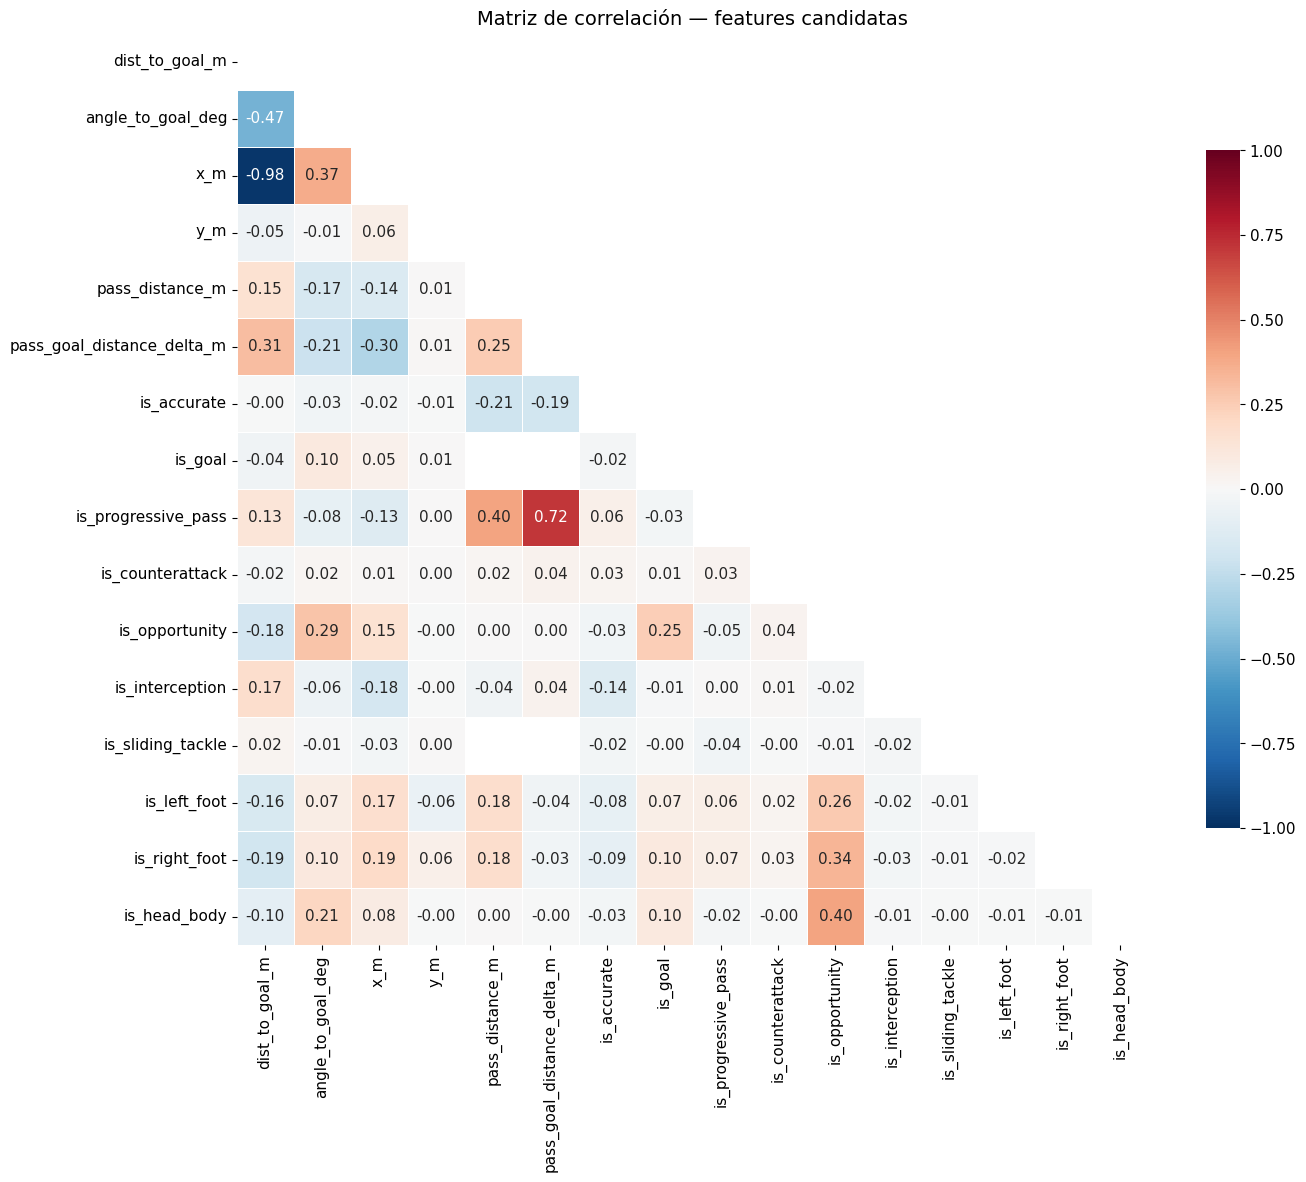

Pares con |correlación| > 0.3:
  dist_to_goal_m                 ↔ x_m                            r = -0.976
  pass_goal_distance_delta_m     ↔ is_progressive_pass            r = +0.718
  dist_to_goal_m                 ↔ angle_to_goal_deg              r = -0.470
  is_opportunity                 ↔ is_head_body                   r = +0.404
  pass_distance_m                ↔ is_progressive_pass            r = +0.402
  angle_to_goal_deg              ↔ x_m                            r = +0.370
  is_opportunity                 ↔ is_right_foot                  r = +0.342
  dist_to_goal_m                 ↔ pass_goal_distance_delta_m     r = +0.309


In [35]:
# Seleccionar features relevantes para xG y clustering
corr_features = [
    'dist_to_goal_m', 'angle_to_goal_deg', 'x_m', 'y_m',
    'pass_distance_m', 'pass_goal_distance_delta_m',
    'is_accurate', 'is_goal', 'is_progressive_pass',
    'is_counterattack', 'is_opportunity',
    'is_interception', 'is_sliding_tackle',
    'is_left_foot', 'is_right_foot', 'is_head_body'
]

corr_df = df[corr_features].corr()

fig, ax = plt.subplots(figsize=(14, 12))
mask = np.triu(np.ones_like(corr_df, dtype=bool))
sns.heatmap(corr_df, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, linewidths=0.5, ax=ax,
            square=True, cbar_kws={'shrink': 0.7})
ax.set_title('Matriz de correlación — features candidatas', fontsize=14)
plt.tight_layout()
plt.savefig('figures/09_correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# Pares más correlacionados
high_corr = []
for i in range(len(corr_df)):
    for j in range(i+1, len(corr_df)):
        if abs(corr_df.iloc[i, j]) > 0.3:
            high_corr.append((corr_df.index[i], corr_df.columns[j], corr_df.iloc[i, j]))

high_corr.sort(key=lambda x: abs(x[2]), reverse=True)
print("Pares con |correlación| > 0.3:")
for feat1, feat2, corr in high_corr:
    print(f"  {feat1:<30} ↔ {feat2:<30} r = {corr:+.3f}")

La matriz de correlación revela tres hallazgos relevantes para el diseño de
features:

**1. Redundancia espacial: `dist_to_goal_m` ↔ `x_m` (r = −0.976).**
Estas dos variables son prácticamente equivalentes: la coordenada longitudinal y
la distancia al gol codifican la misma información. Para el modelo xG se usará
`dist_to_goal_m` (más interpretable y generalizable) y se excluirá `x_m` para
evitar multicolinealidad. Para el clustering, donde las features se agregan por
jugador, `x_m` medio ya no será redundante con distancia de tiro.

**2. Coherencia de features derivadas: `pass_goal_distance_delta_m` ↔
`is_progressive_pass` (r = +0.718).**
La correlación alta es esperada: `is_progressive_pass` es la versión binarizada
(umbral ≥10m) de `pass_goal_distance_delta_m`. Para el clustering se recomienda
usar la versión continua, que captura más varianza.

**3. Correlación moderada distancia-ángulo (r = −0.470).**
Ambas features comparten información pero no son redundantes (r² = 0.22).
Incluir ambas en el modelo xG es correcto y está alineado con la práctica
estándar en la literatura.

Las correlaciones confirman la necesidad de **PCA antes del clustering**: variables
como `x_m`, `dist_to_goal_m`, `pass_distance_m` y `pass_goal_distance_delta_m`
comparten estructura que la reducción de dimensionalidad comprimirá en componentes
ortogonales.

## 10. Conclusiones del EDA y conexión con las fases posteriores

El análisis exploratorio de los 3.071.395 eventos de las cinco grandes ligas europeas
(temporada 2017/18, Pappalardo et al., 2019) ha cumplido tres objetivos:

### 10.1 Validación del dataset

- Los conteos de eventos coinciden exactamente con las cifras publicadas en el paper
  original, confirmando la integridad del pipeline ETL Bronze → Silver.
- Se identificaron y documentaron artefactos de coordenadas propios del dataset Wyscout:
  acumulación en esquinas (~2.3%) y líneas de banda (~7.6%), con tratamiento diferenciado
  para las visualizaciones.
- La auditoría cruzada de los 57 tag IDs contra la documentación oficial de Wyscout
  (socceraction, ML-KULeuven) confirmó que los 32 tags mapeados en Silver son correctos.
  Se documentó la ausencia del tag 1501 (`clearance`) en el dataset público.
- La simetría vertical del campo (ratio 0.978) y la estabilidad del volumen de eventos
  a lo largo del partido confirman la fiabilidad del registro.

### 10.2 Features validadas para el modelo xG

El análisis de los 40.461 tiros (excluyendo penaltis y faltas directas) valida las
siguientes features:

| Feature | Tipo | Evidencia |
|---|---|---|
| `dist_to_goal_m` | Continua | Decaimiento exponencial: 18.0% dentro del área vs 3.9% fuera (ratio 4.6x) |
| `angle_to_goal_deg` | Continua | Relación monótona creciente: ~5% en ángulos <10° a ~55% en >65° |
| `body_part` | Categórica | Cabeza 12.6% vs pie ~10%, pero confundido con distancia (cabezazos a 10.5m) |
| `is_counterattack` | Binaria | +4.3pp sobre tasa base (14.9% vs 10.6%) |
| `is_opportunity` | Binaria | Cobertura del 70% — utilidad limitada como discriminador |

Las features del evento previo al tiro (Tier 2: `prev_event_type`, `prev_is_cross`,
`is_rebound`, `fast_attack`) se construirán en la fase de modelado. La correlación
`dist_to_goal_m` ↔ `x_m` (r = −0.976) confirma que son redundantes: se usará
`dist_to_goal_m` para el xG y se excluirá `x_m`.

### 10.3 Features candidatas para el clustering de estilos

El análisis de pases, acciones defensivas y comparación entre ligas proporciona la
base para construir ~80 features per90 por jugador:

**Ofensivas:** % pases progresivos, % smart passes, % crosses, precisión en el último
tercio, pass_goal_distance_delta_m medio, tiros per90, xG per90 (del modelo propio).

**Defensivas:** duelos aéreos ganados per90, duelos terrestres defensivos per90,
intercepciones per90, entradas per90, faltas cometidas per90. Se usarán features
granulares por sub_event_name (no genéricas) para maximizar la discriminación entre
perfiles.

**De posesión:** pases per90, precisión de pase global, pases largos per90, pases
de mano per90 (porteros).

### 10.4 Decisiones metodológicas derivadas del EDA

1. **Clustering por grupo posicional**, no global — la huella espacial y el perfil
   defensivo difieren radicalmente entre posiciones.
2. **Umbral de inclusión ≥10 partidos** — 1.947 jugadores viables (75.8%).
3. **Modelo xG entrenado sobre Big 5 conjuntas** — las diferencias entre ligas son
   de segundo orden (precisión 82–83%, conversión 9.7–11.1%).
4. **PCA antes del clustering** — las correlaciones entre features espaciales
   confirman redundancia que la reducción de dimensionalidad comprimirá.
5. **Normalización per90** — validada por la estabilidad temporal del volumen de
   eventos.

### Roadmap de las siguientes fases

| Fase | Input | Output |
|---|---|---|
| **Modelo xG** | 40.461 tiros + ~12-15 features (Tier 1+2) | P(gol) por tiro → xG per90 por jugador |
| **Agregación per90** | event_enriched → player_season_agg | ~80 features por jugador-temporada |
| **Clustering** | Features per90 + PCA por grupo posicional | K clusters por posición + interpretación |
| **Motor de similitud** | Espacio PCA | Top-N jugadores similares a uno dado |
| **Predicción t→t+1** | Kaggle FBref 21/22 → 22/23 | XGBoost + SHAP |

In [36]:
print("\n" + "=" * 60)
print("EDA COMPLETADO")
print("=" * 60)
print(f"\nSecciones completadas: 11")
print(f"Figuras generadas: {len([f for f in os.listdir('figures') if f.endswith('.png')])}")
print(f"\nPróximo paso: Modelo xG propio (regresión logística + XGBoost)")
print(f"Dataset de entrenamiento: 40,461 tiros | 4,271 goles (10.6%)")


EDA COMPLETADO

Secciones completadas: 11
Figuras generadas: 26

Próximo paso: Modelo xG propio (regresión logística + XGBoost)
Dataset de entrenamiento: 40,461 tiros | 4,271 goles (10.6%)
